In [ ]:
!pip install diffusers transformers accelerate controlnet_aux torch
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
from diffusers import StableDiffusionInpaintPipeline
import torch

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    use_safetensors=False  # Forces it to use .bin files
).to("cuda")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

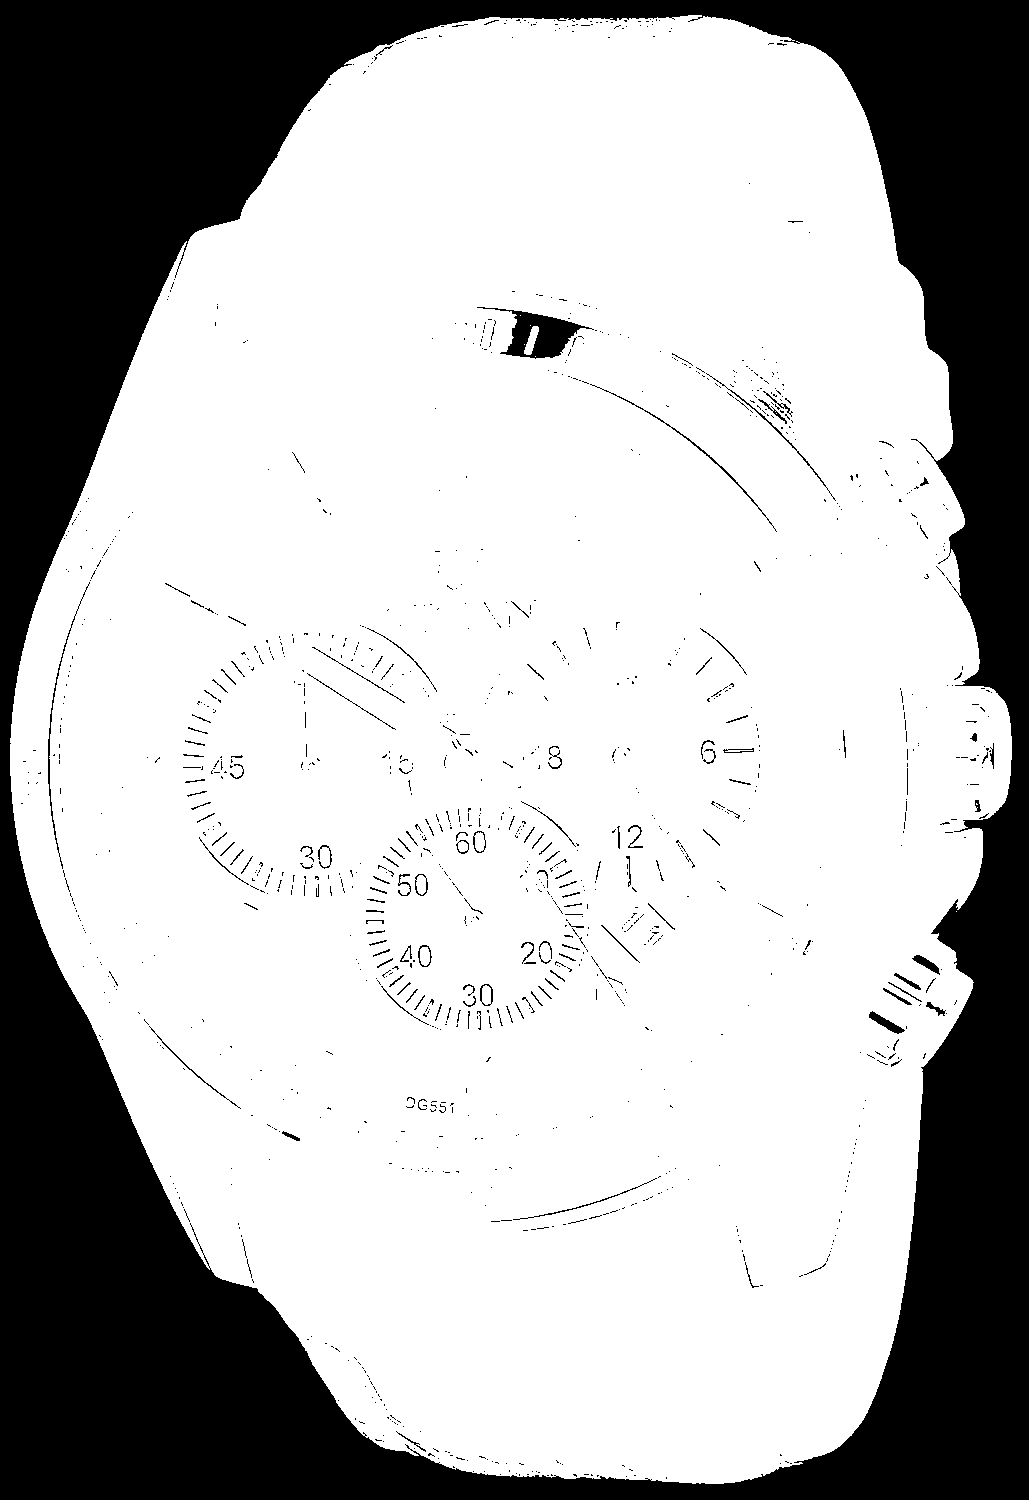

In [ ]:
import cv2
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow # Import cv2_imshow

# Load product image
product_id = "44983"  # Replace with actual product ID
image_path = f"/content/watch.jpg"
image = cv2.imread(image_path)

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Threshold to create a binary mask (adjust threshold value as needed)
_, mask = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)

# Save mask
mask_path = "/content/mask.jpg"
cv2.imwrite(mask_path, mask)

# Convert OpenCV image to PIL format for Stable Diffusion
product_image = Image.open(image_path).convert("RGB")
mask_image = Image.open(mask_path).convert("L")

# Display the mask using cv2_imshow and wait for a key press
cv2_imshow(mask) # Use cv2_imshow instead of cv2.imshow

# Remove the problematic lines
# cv2.waitKey(0)
# cv2.destroyAllWindows()

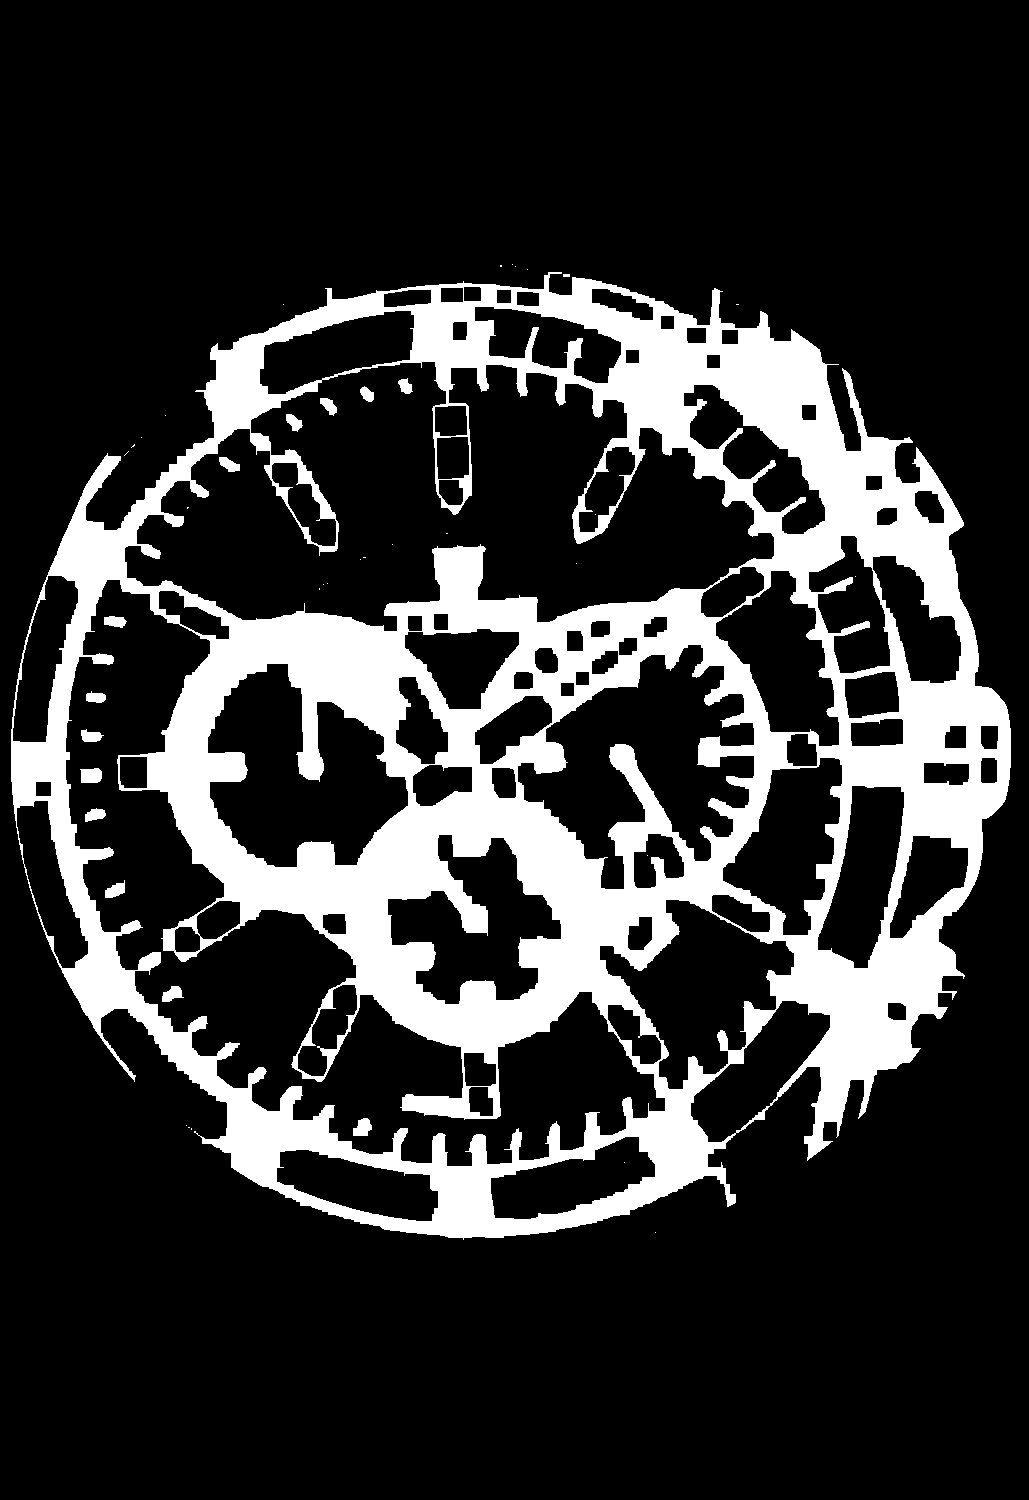

In [ ]:
import cv2
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow

# Load image
image_path = "/content/watch.jpg"
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Use adaptive thresholding to handle lighting variations
mask = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 10
)

# Apply morphological operations to close gaps
kernel = np.ones((7, 7), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Optional: Use a circular mask for better results
h, w = mask.shape
center = (w // 2, h // 2)
radius = min(w, h) // 2 - 10
circular_mask = np.zeros_like(mask)
cv2.circle(circular_mask, center, radius, 255, thickness=-1)

# Apply circular mask to refine the result
mask = cv2.bitwise_and(mask, circular_mask)

# Save and display mask
mask_path = "/content/fixed_mask.jpg"
cv2.imwrite(mask_path, mask)
cv2_imshow(mask)

# Convert for Stable Diffusion
product_image = Image.open(image_path).convert("RGB")
mask_image = Image.open(mask_path).convert("L")


**under this section i tried to create bg,create a small area in it for inlay,and inlay the extracted product image 🌸**











In [ ]:
from diffusers import StableDiffusionPipeline, StableDiffusionInpaintPipeline
import torch
from PIL import Image, ImageDraw

# Check device availability
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the background generation model
base_model = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)

# Load the inpainting model for product integration
inpaint_model = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)

print("Models loaded successfully!")


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Models loaded successfully!


In [ ]:
!pip install rembg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install diffusers transformers accelerate safetensors


In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.4 MB/s eta 0:00:00


**NEW CODE FOR BACKGROUND GENERATION**

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

# Load the model (ensure you're using the correct model path)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe.to("cuda")  # Move model to GPU if available


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.34.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [ ]:
!pip install -U bitsandbytes
!pip install diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 16.8 MB/s eta 0:00:00


In [ ]:
!pip install -U bitsandbytes

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = 'filipealmeida/Mistral-7B-Instruct-v0.1-sharded'

from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from accelerate import init_empty_weights
import torch

def load_quantized_model(model_name):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        llm_int8_enable_fp32_cpu_offload=True  # enable CPU offload
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",  # will offload some layers to CPU if needed
        trust_remote_code=True
    )

    model.to("cuda" if torch.cuda.is_available() else "cpu")
    return model


def initialize_tokenizer(model_name: str):
    """
    Initialize the tokenizer with the specified model name.

    :param model_name: Name or path of the model for tokenizer initialization.
    :return: Initialized tokenizer.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.bos_token_id = 1  # Set beginning of sentence token id
    return tokenizer

# Load the model and tokenizer
model = load_quantized_model(model_name)
tokenizer = initialize_tokenizer(model_name)
stop_token_ids = [0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

In [ ]:
def generate_response(prompt):
    """
    Generate a response from the model for the given prompt.

    :param prompt: The input prompt to generate a response for.
    :return: Generated response.
    """
    import torch

    # Instead of model.device, detect device manually
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # If your model is not already on device, you might need to move it ONCE outside this function, not here
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    output = model.generate(
        **inputs,
        temperature=1.0,
        max_new_tokens=2048,
        num_return_sequences=1
    )

    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response



def generate_prompt_for_ad_background(data):
    """
    Generate a concise prompt for creating an advertisement background based on product metadata.
    The background should not contain the product or any people and should be no longer than 5 lines.

    :param data: Dictionary containing product information like gender, baseColour, season, etc.
    :return: A prompt string for the model.
    """
    description_parts = []

    if "gender" in data:
        description_parts.append(f"designed for {data['gender'].lower()}")
    if "baseColour" in data:
        description_parts.append(f"features a {data['baseColour'].lower()} color scheme")
    # if "season" in data:
    #     description_parts.append(f"suitable for the {data['season'].lower()} season")
    if "usage" in data:
        description_parts.append(f"intended for {data['usage'].lower()} use")
    # if "articleType" in data:
    #     description_parts.append(f"is a {data['articleType'].lower()}")
    if "subCategory" in data:
        description_parts.append(f"under the {data['subCategory'].lower()} category")
    if "masterCategory" in data:
        description_parts.append(f"part of the {data['masterCategory'].lower()} collection")
    if "year" in data:
        description_parts.append(f"from the year {data['year']}")

    # Join all parts into a sentence
    product_description = "This product " + ", ".join(description_parts) + "."

    return (
        f"Context: {product_description}\n\n"
        "Instructions: Generate a premium advertisement background with NO furniture, people, objects, or interior elements. "
        "Do NOT include chairs, tables, windows, walls, floors, or any realistic room structures.\n\n"
        "Instead, focus on creating a minimal, high-fashion ad-style background using abstract elements like: soft gradients, flowing textures, reflective surfaces, lighting effects, or subtle geometric designs. "
        "The goal is to create an elegant, clean canvas that highlights the product (which will be added later).\n\n"
        "Only output the 'Ad Background' in 5 lines — no extra text or labels.\n\n"
        "Ad Background:"
    )






In [ ]:
# Example product metadata
product_data = {
    "gender": "women",
    "baseColour": "silver",
    # "season": "winter",
    "usage": "casual",
    # "articleType": "watches",
    "subCategory": "watches",
    "masterCategory": "accessories",
    "year": 2016
}


# Step 1: Generate the ad background prompt
ad_prompt = generate_prompt_for_ad_background(product_data)

# Step 2: Generate the response using the model
ad_background = generate_response(ad_prompt)

# Step 3: Print the generated ad background
print("now printing response generated by the mistral llm")
print(ad_background)

NameError: name 'tokenizer' is not defined

In [ ]:
def extract_ad_background(response):
    # Split the response at "Ad Background:" and take the part after it
    ad_background_start = "Ad Background:"
    if ad_background_start in response:
        return response.split(ad_background_start, 1)[1].strip()  # Remove leading/trailing spaces
    return None  # Return None if "Ad Background:" isn't found

# Example of how to extract the Ad Background
ad_background_text = extract_ad_background(ad_background)
print(ad_background_text)

NameError: name 'ad_background' is not defined

In [ ]:
#!pip install diffusers transformers accelerate safetensors

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline # Import StableDiffusionPipeline
import torch

# Assuming you want to use the "runwayml/stable-diffusion-v1-5" model
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe.to("cuda")  # Move model to GPU if available


print(ad_background_text)

# Generate the background image
background_image = pipe(ad_background_text).images[0]

# Save the background image
background_image.save("generated_background.png")
print("Background generated successfully!")

# Display the image
plt.imshow(background_image)
plt.axis("off")
plt.title("Generated Background")
plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

NameError: name 'ad_background_text' is not defined

In [ ]:
!pip install gradio transformers diffusers accelerate safetensors torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.1 MB/s eta 0:00:00


In [ ]:
def run_generation(gender, baseColour, usage, subCategory, masterCategory, year):
    # Step 1: Prepare metadata dictionary
    product_data = {
        "gender": gender,
        "baseColour": baseColour,
        "usage": usage,
        "subCategory": subCategory,
        "masterCategory": masterCategory,
        "year": year
    }

    # Step 2: Generate prompt
    ad_prompt = generate_prompt_for_ad_background(product_data)

    # Step 3: Generate response using Mistral
    ad_background = generate_response(ad_prompt)

    # Step 4: Extract the Ad Background text
    ad_background_text = extract_ad_background(ad_background)

    # Step 5: Generate image using Stable Diffusion
    image = pipe(ad_background_text).images[0]

    return ad_background_text, image


In [ ]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("## 🖼️ Ad Background Generator")

    with gr.Row():
        gender = gr.Textbox(label="Gender")
        baseColour = gr.Textbox(label="Base Colour")
        usage = gr.Textbox(label="Usage")

    with gr.Row():
        subCategory = gr.Textbox(label="Subcategory")
        masterCategory = gr.Textbox(label="Master Category")
        year = gr.Number(label="Year")

    generate_button = gr.Button("Generate Background")

    ad_text_output = gr.Textbox(label="Generated Background Description", lines=5)
    image_output = gr.Image(label="Generated Background Image")

    generate_button.click(
        fn=run_generation,
        inputs=[gender, baseColour, usage, subCategory, masterCategory, year],
        outputs=[ad_text_output, image_output]
    )

demo.launch(share=True,debug=True)  # `share=True` creates a public link for Colab


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e5fd6d59057aae0d7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2136, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 1662, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7863 <> https://e5fd6d59057aae0d7b.gradio.live


**WORKING WITH THE ACTUAL PRODUCT FROM HERE**

In [ ]:
!pip install --upgrade numpy # Upgrade NumPy to the latest compatible version
!pip install --upgrade numba # Upgrade Numba to the latest version
!pip install --upgrade rembg # Upgrade rembg to the latest version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.2 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 78.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0,

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.5 MB/s eta 0:00:00


In [ ]:
from diffusers import StableDiffusionPipeline, StableDiffusionInpaintPipeline
import torch
from PIL import Image, ImageDraw
import numpy as np
from rembg import remove

In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.2 MB/s eta 0:00:00


In [ ]:
from PIL import Image

def resize_image(input_path, output_path, size=(512, 512)):
    # Open the image
    img = Image.open(input_path)

    # Resize
    img_resized = img.resize(size)

    # Save the resized image
    img_resized.save(output_path)
    print(f"✅ Image saved at {output_path}")

# Example usage
resize_image("bg12.jpg", "bg12_new.jpg")


✅ Image saved at bg12_new.jpg


✅ Product background removed


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-8-12 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


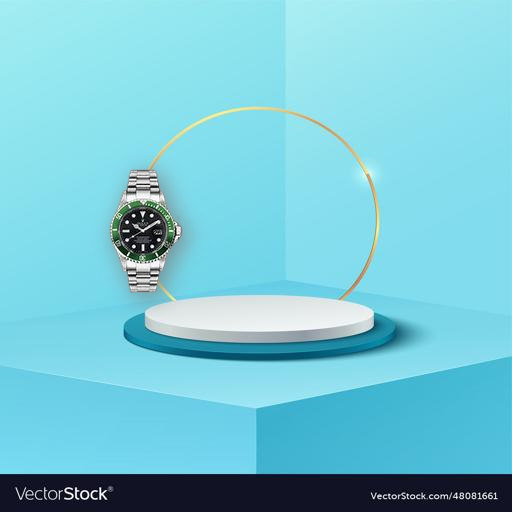

✅ Final ad created with smart placement!


In [ ]:
from PIL import Image, ImageDraw, ImageStat, ImageFilter
import numpy as np
import random
from rembg import remove
from IPython.display import display
import torch

# === Step 1: Load Product and Remove Background ===
product_with_bg = Image.open("/content/watch3.jpg").convert("RGB")
product_no_bg = remove(product_with_bg)  # Transparent RGBA
product_no_bg.save("/content/product_extracted.png")
print("✅ Product background removed")

#=== Step 2: Resize Product ===
scale_factor = 0.9
new_width = int(product_no_bg.width * scale_factor)
new_height = int(product_no_bg.height * scale_factor)
product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)




# === Step 3: Create Shadow ===
def create_shadow(product_image, blur_radius=10, opacity=0.5):
    shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
    mask = product_image.split()[3]
    shadow_pixels = shadow.load()
    mask_pixels = mask.load()
    for y in range(shadow.height):
        for x in range(shadow.width):
            if mask_pixels[x, y] > 0:
                shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))
    shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    return shadow

product_shadow = create_shadow(product_no_bg)

# === Step 4: Load Background ===
background_image_path = "/content/bg4_new.jpg"
background_image = Image.open(background_image_path).convert("RGBA")

# === Step 5: Object Detection to Avoid ===
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
results = model(background_image)
detections = results.pandas().xyxy[0]
avoid_classes = ['person', 'cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'tree']
avoid_boxes = [
    (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    for _, row in detections.iterrows() if row['name'] in avoid_classes
]

def is_overlapping(x, y, product_size, boxes):
    px1, py1 = x, y
    px2, py2 = x + product_size[0], y + product_size[1]
    for bx1, by1, bx2, by2 in boxes:
        if not (px2 < bx1 or px1 > bx2 or py2 < by1 or py1 > by2):
            return True
    return False

# === Step 6: Simulated Semantic Segmentation ===
# For demo: simulate a sky region at top 25% of image, ground at bottom
segmentation_map = Image.new("L", background_image.size)
seg_draw = ImageDraw.Draw(segmentation_map)
seg_draw.rectangle([0, 0, background_image.width, background_image.height * 0.25], fill=2)  # Sky
seg_draw.rectangle([0, background_image.height * 0.25, background_image.width, background_image.height], fill=1)  # Ground

def segment_score(segmentation_map, position, product_size):
    x, y = position
    region = segmentation_map.crop((x, y, x + product_size[0], y + product_size[1]))
    arr = np.array(region)
    ground_pixels = np.sum(arr == 1)
    sky_pixels = np.sum(arr == 2)
    return ground_pixels - sky_pixels

# === Step 7: Placement Scoring Function ===
def score_region(region, position, image_size, segmentation_map):
    region_gray = region.convert('L')
    stats = ImageStat.Stat(region_gray)
    variance = stats.var[0]
    mean_brightness = stats.mean[0]

    norm_variance = max(0, 1 - (variance / 1000))
    norm_brightness = 1 - abs(mean_brightness - 128) / 128

    x, y = position
    _, img_height = image_size
    vertical_bias = 1 - (y / img_height)

    seg_score = segment_score(segmentation_map, position, region.size) / (region.size[0] * region.size[1])  # Normalize

    return (
        norm_variance * 0.5 +
        norm_brightness * 0.5 +
        vertical_bias * 0.3 +
        seg_score * 0.5
    )

# === Step 8: Find Best Placement ===
def find_best_placement(background, product_size, avoid_boxes, segmentation_map):
    width, height = background.size
    step_size = 50
    best_score = -1
    best_position = None

    for y in range(0, height - product_size[1], step_size):
        for x in range(0, width - product_size[0], step_size):
            if is_overlapping(x, y, product_size, avoid_boxes):
                continue
            region = background.crop((x, y, x + product_size[0], y + product_size[1]))
            score = score_region(region, (x, y), (width, height), segmentation_map)
            if score > best_score:
                best_score = score
                best_position = (x, y)

    return best_position

product_position = find_best_placement(background_image, product_no_bg.size, avoid_boxes, segmentation_map)
if not product_position:
    product_position = (
        (background_image.width - product_no_bg.width) // 2,
        (background_image.height - product_no_bg.height) // 2
    )

# === Step 9: Composite Final Ad ===
final_image = background_image.copy()
shadow_position = (product_position[0] + 5, product_position[1] + 5)
final_image.paste(product_shadow, shadow_position, product_shadow)
final_image.paste(product_no_bg, product_position, product_no_bg)
final_image.save("/content/final_ad_with_shadow.png")

# === Step 10: Show Output ===
display(final_image)
print("✅ Final ad created with smart placement!")


✅ Product background removed


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-8-12 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


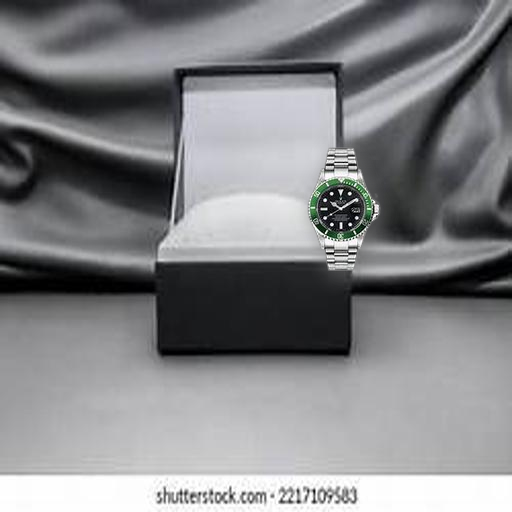

✅ Final ad created with smart placement!


In [ ]:
#version 2

from PIL import Image, ImageDraw, ImageStat, ImageFilter
import numpy as np
import random
from rembg import remove
from IPython.display import display
import torch

# === Step 1: Load Product and Remove Background ===
product_with_bg = Image.open("/content/watch3.jpg").convert("RGB")
product_no_bg = remove(product_with_bg)  # Transparent RGBA
product_no_bg.save("/content/product_extracted.png")
print("✅ Product background removed")

# === Step 2: Resize Product ===
scale_factor = 0.9
new_width = int(product_no_bg.width * scale_factor)
new_height = int(product_no_bg.height * scale_factor)
product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)



product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)

# === Step 3: Create Shadow ===
def create_shadow(product_image, blur_radius=10, opacity=0.5):
    shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
    mask = product_image.split()[3]
    shadow_pixels = shadow.load()
    mask_pixels = mask.load()
    for y in range(shadow.height):
        for x in range(shadow.width):
            if mask_pixels[x, y] > 0:
                shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))
    shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    return shadow

product_shadow = create_shadow(product_no_bg)

# === Step 4: Load Background ===
background_image_path = "/content/bg2.jpg"
background_image = Image.open(background_image_path).convert("RGBA")

# === Step 5: Object Detection to Avoid ===
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
results = model(background_image)
detections = results.pandas().xyxy[0]
avoid_classes = ['person', 'cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'tree']
avoid_boxes = [
    (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    for _, row in detections.iterrows() if row['name'] in avoid_classes
]

def is_overlapping(x, y, product_size, boxes):
    px1, py1 = x, y
    px2, py2 = x + product_size[0], y + product_size[1]
    for bx1, by1, bx2, by2 in boxes:
        if not (px2 < bx1 or px1 > bx2 or py2 < by1 or py1 > by2):
            return True
    return False

# === Step 6: Simulated Semantic Segmentation ===
# For demo: simulate a sky region at top 25% of image, ground at bottom
segmentation_map = Image.new("L", background_image.size)
seg_draw = ImageDraw.Draw(segmentation_map)
seg_draw.rectangle([0, 0, background_image.width, background_image.height * 0.25], fill=2)  # Sky
seg_draw.rectangle([0, background_image.height * 0.25, background_image.width, background_image.height], fill=1)  # Ground

def segment_score(segmentation_map, position, product_size):
    x, y = position
    region = segmentation_map.crop((x, y, x + product_size[0], y + product_size[1]))
    arr = np.array(region)
    ground_pixels = np.sum(arr == 1)
    sky_pixels = np.sum(arr == 2)
    return ground_pixels - sky_pixels

# === Step 7: Placement Scoring Function ===
def score_region(region, position, image_size, segmentation_map):
    region_gray = region.convert('L')
    stats = ImageStat.Stat(region_gray)
    variance = stats.var[0]
    mean_brightness = stats.mean[0]

    norm_variance = max(0, 1 - (variance / 1000))
    norm_brightness = 1 - abs(mean_brightness - 128) / 128

    x, y = position
    _, img_height = image_size
    vertical_bias = 1 - (y / img_height)

    seg_score = segment_score(segmentation_map, position, region.size) / (region.size[0] * region.size[1])  # Normalize

    return (
        norm_variance * 0.5 +
        norm_brightness * 0.5 +
        vertical_bias * 0.3 +
        seg_score * 0.5
    )

# # === Step 8: Find Best Placement (Pixel-by-Pixel) ===
def find_best_placement(background, product_size, avoid_boxes, segmentation_map):
    width, height = background.size
    best_score = -1
    best_position = None

    for y in range(0, height - product_size[1]):  # Every pixel vertically
        for x in range(0, width - product_size[0]):  # Every pixel horizontally
            if is_overlapping(x, y, product_size, avoid_boxes):
                continue
            region = background.crop((x, y, x + product_size[0], y + product_size[1]))
            score = score_region(region, (x, y), (width, height), segmentation_map)
            if score > best_score:
                best_score = score
                best_position = (x, y)

    return best_position


product_position = find_best_placement(background_image, product_no_bg.size, avoid_boxes, segmentation_map)
if not product_position:
    product_position = (
        (background_image.width - product_no_bg.width) // 2,
        (background_image.height - product_no_bg.height) // 2
    )

# === Step 9: Composite Final Ad ===
final_image = background_image.copy()
shadow_position = (product_position[0] + 5, product_position[1] + 5)
final_image.paste(product_shadow, shadow_position, product_shadow)
final_image.paste(product_no_bg, product_position, product_no_bg)
final_image.save("/content/final_ad_with_shadow.png")

# === Step 10: Show Output ===
display(final_image)
print("✅ Final ad created with smart placement!")


/usr/local/lib/python3.12/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-8-21 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

100%|██████████| 14.1M/14.1M [00:00<00:00, 109MB/s] 

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
100%|████████████████████████████████████████| 176M/176M [00:00<00:00, 212GB/s]


🔍 Detecting platforms...
📊 Found 1 potential platforms:
  Platform 1: circular
✅ Selected circular platform for placement


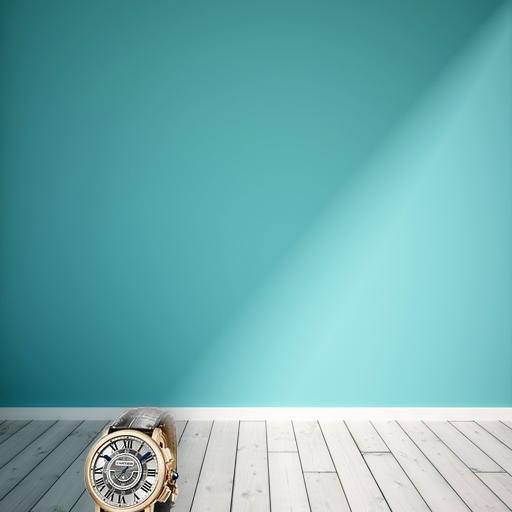

✅ Product placed on detected platform!


In [ ]:
#VERSION 3
from PIL import Image, ImageDraw, ImageStat, ImageFilter, ImageEnhance
import numpy as np
import cv2
import random
from rembg import remove
from IPython.display import display
import torch
from scipy import ndimage
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

class PlatformSurfaceDetector:
    def __init__(self):
        self.model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

    def detect_circular_platforms(self, image):
        """Detect circular platforms and pedestals"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (9, 9), 2)

        # Detect circles using HoughCircles
        circles = cv2.HoughCircles(
            blurred,
            cv2.HOUGH_GRADIENT,
            dp=1,
            minDist=50,
            param1=50,
            param2=30,
            minRadius=20,
            maxRadius=200
        )

        detected_platforms = []
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (x, y, r) in circles:
                # Validate if this looks like a platform top
                if self.validate_platform_surface(cv_image, x, y, r):
                    detected_platforms.append({
                        'center': (x, y),
                        'radius': r,
                        'type': 'circular',
                        'surface_rect': (x-r, y-r, x+r, y+r)
                    })

        return detected_platforms

    def detect_rectangular_platforms(self, image):
        """Detect rectangular platforms and surfaces"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

        # Edge detection
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)

        # Find contours
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detected_platforms = []
        for contour in contours:
            # Approximate contour to polygon
            epsilon = 0.02 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)

            # Check if it's roughly rectangular (4 sides) and large enough
            if len(approx) == 4:
                area = cv2.contourArea(contour)
                if area > 1000:  # Minimum area threshold
                    # Get bounding rectangle
                    x, y, w, h = cv2.boundingRect(contour)

                    # Validate aspect ratio (not too elongated)
                    aspect_ratio = w / h
                    if 0.3 < aspect_ratio < 3.0:
                        detected_platforms.append({
                            'contour': approx,
                            'bbox': (x, y, x+w, y+h),
                            'type': 'rectangular',
                            'surface_rect': (x, y, x+w, y+h)
                        })

        return detected_platforms

    def detect_platform_tops_by_color(self, image):
        """Detect platform tops by identifying flat, uniform colored surfaces"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)

        # Convert to HSV for better color segmentation
        hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

        # Apply bilateral filter to reduce noise while keeping edges sharp
        filtered = cv2.bilateralFilter(cv_image, 9, 75, 75)

        # Find regions with low variance (flat surfaces)
        gray = cv2.cvtColor(filtered, cv2.COLOR_BGR2GRAY)

        # Apply morphological operations to find solid regions
        kernel = np.ones((5,5), np.uint8)
        opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

        # Find contours of potential platform surfaces
        edges = cv2.Canny(opened, 30, 80)
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        platform_surfaces = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 500:  # Minimum area for a platform
                # Get bounding box
                x, y, w, h = cv2.boundingRect(contour)

                # Check if the region has low color variance (uniform surface)
                roi = cv_image[y:y+h, x:x+w]
                if roi.size > 0:
                    color_variance = np.var(roi.reshape(-1, 3), axis=0).mean()

                    if color_variance < 800:  # Low variance indicates uniform surface
                        # Check if it's roughly horizontal (platform-like)
                        aspect_ratio = w / h
                        if aspect_ratio > 0.5:  # Not too tall/thin
                            platform_surfaces.append({
                                'bbox': (x, y, x+w, y+h),
                                'center': (x + w//2, y + h//2),
                                'type': 'color_uniform',
                                'surface_rect': (x, y, x+w, y+h),
                                'variance': color_variance
                            })

        # Sort by lowest variance (most uniform = most likely to be platform top)
        platform_surfaces.sort(key=lambda x: x['variance'])

        return platform_surfaces

    def validate_platform_surface(self, image, center_x, center_y, radius):
        """Validate if a detected circle is actually a platform surface"""
        h, w = image.shape[:2]

        # Check bounds
        if center_x - radius < 0 or center_x + radius >= w:
            return False
        if center_y - radius < 0 or center_y + radius >= h:
            return False

        # Extract the circular region
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, (center_x, center_y), radius, 255, -1)

        # Calculate color variance within the circle
        roi = cv2.bitwise_and(image, image, mask=mask)
        roi_pixels = roi[mask > 0]

        if len(roi_pixels) > 0:
            variance = np.var(roi_pixels)
            # Platform surfaces should have low variance (uniform color)
            return variance < 1000

        return False

    def find_best_platform_placement(self, platforms, product_size, image_size):
        """Find the best platform to place the product on"""
        if not platforms:
            return None

        best_platform = None
        best_score = -1

        img_width, img_height = image_size
        product_width, product_height = product_size

        for platform in platforms:
            score = 0

            if platform['type'] == 'circular':
                center_x, center_y = platform['center']
                radius = platform['radius']

                # Check if product fits on the circular platform
                if product_width < radius * 1.5 and product_height < radius * 1.5:
                    score += 1.0  # Fits well

                    # Prefer platforms in lower half of image (more natural)
                    if center_y > img_height * 0.4:
                        score += 0.5

                    # Prefer larger platforms
                    size_score = min(1.0, radius / 100)
                    score += size_score * 0.3

            elif platform['type'] in ['rectangular', 'color_uniform']:
                x1, y1, x2, y2 = platform['surface_rect']
                platform_width = x2 - x1
                platform_height = y2 - y1

                # Check if product fits
                if product_width < platform_width * 0.8 and product_height < platform_height * 0.8:
                    score += 1.0

                    # Prefer platforms in lower half
                    center_y = (y1 + y2) // 2
                    if center_y > img_height * 0.4:
                        score += 0.5

                    # Prefer platforms that aren't too small
                    area_score = min(1.0, (platform_width * platform_height) / (img_width * img_height * 0.1))
                    score += area_score * 0.3

            if score > best_score:
                best_score = score
                best_platform = platform

        return best_platform

    def calculate_product_position_on_platform(self, platform, product_size, image_size):
        """Calculate the exact position to place product on platform"""
        product_width, product_height = product_size

        if platform['type'] == 'circular':
            center_x, center_y = platform['center']
            # Place product at center of circular platform
            x = center_x - product_width // 2
            y = center_y - product_height // 2

        else:  # rectangular or color_uniform
            x1, y1, x2, y2 = platform['surface_rect']
            platform_center_x = (x1 + x2) // 2
            platform_center_y = (y1 + y2) // 2

            # Place product at center of platform
            x = platform_center_x - product_width // 2
            y = platform_center_y - product_height // 2

        return (int(x), int(y))

    def create_platform_aware_shadow(self, product_image, platform, product_position):
        """Create shadow that fits the platform"""
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]

        # Adjust shadow based on platform type
        if platform['type'] == 'circular':
            # Circular platform - create softer, more diffused shadow
            blur_radius = 12
            opacity = 0.3
            offset_x, offset_y = 3, 3
        else:
            # Rectangular platform - create more defined shadow
            blur_radius = 8
            opacity = 0.4
            offset_x, offset_y = 5, 5

        # Create shadow
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()

        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return shadow, (offset_x, offset_y)

    def process_with_platform_detection(self, product_path, background_path, scale_factor=0.9):
        """Main processing function with platform detection"""
        # Load product
        product_with_bg = Image.open(product_path).convert("RGB")
        product_no_bg = remove(product_with_bg)

        # Resize product
        new_width = int(product_no_bg.width * scale_factor)
        new_height = int(product_no_bg.height * scale_factor)
        product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)

        # Load background
        background_image = Image.open(background_path).convert("RGBA")

        print("🔍 Detecting platforms...")

        # Detect different types of platforms
        circular_platforms = self.detect_circular_platforms(background_image)
        rectangular_platforms = self.detect_rectangular_platforms(background_image)
        color_platforms = self.detect_platform_tops_by_color(background_image)

        # Combine all detected platforms
        all_platforms = circular_platforms + rectangular_platforms + color_platforms[:3]  # Top 3 color platforms

        print(f"📊 Found {len(all_platforms)} potential platforms:")
        for i, platform in enumerate(all_platforms):
            print(f"  Platform {i+1}: {platform['type']}")

        # Find best platform
        best_platform = self.find_best_platform_placement(
            all_platforms, product_no_bg.size, background_image.size
        )

        if best_platform:
            print(f"✅ Selected {best_platform['type']} platform for placement")

            # Calculate position on platform
            product_position = self.calculate_product_position_on_platform(
                best_platform, product_no_bg.size, background_image.size
            )

            # Create platform-aware shadow
            product_shadow, shadow_offset = self.create_platform_aware_shadow(
                product_no_bg, best_platform, product_position
            )

        else:
            print("⚠️ No suitable platform found, using center placement")
            product_position = (
                (background_image.width - product_no_bg.width) // 2,
                (background_image.height - product_no_bg.height) // 2
            )

            # Create basic shadow
            shadow = Image.new("RGBA", product_no_bg.size, (0, 0, 0, 0))
            mask = product_no_bg.split()[3]
            shadow_pixels = shadow.load()
            mask_pixels = mask.load()
            for y in range(shadow.height):
                for x in range(shadow.width):
                    if mask_pixels[x, y] > 0:
                        shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * 0.4))
            product_shadow = shadow.filter(ImageFilter.GaussianBlur(radius=10))
            shadow_offset = (5, 5)

        # Composite final image
        final_image = background_image.copy()

        # Add shadow
        shadow_position = (
            product_position[0] + shadow_offset[0],
            product_position[1] + shadow_offset[1]
        )
        final_image.paste(product_shadow, shadow_position, product_shadow)

        # Add product
        final_image.paste(product_no_bg, product_position, product_no_bg)

        return final_image, all_platforms, best_platform

# Usage:
detector = PlatformSurfaceDetector()
final_image, detected_platforms, selected_platform = detector.process_with_platform_detection(
    "/content/watch2.jpg",
    "/content/bg5_new.jpg"
)

final_image.save("/content/platform_placement_result.png")
display(final_image)
print("✅ Product placed on detected platform!")

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-8-21 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


🚀 Starting platform detection process...
📏 Product resized to: 144x161
🖼️ Background size: (512, 512)
🔍 Analyzing image for 3D rendered platforms...
📊 White regions detected: 92342 pixels
   Contour area: 11.0
   Contour area: 17.0
   Contour area: 29.0
   Contour area: 25.0
   Contour area: 13.5
   Contour area: 18.5
   Contour area: 50.0
   Contour area: 14.5
   Contour area: 31.5
   Contour area: 55.5
   Contour area: 40.5
   Contour area: 76.0
   Contour area: 249.5
   Contour area: 0.0
   Contour area: 3.5
   Contour area: 60.0
   Contour area: 1.5
   Contour area: 10.5
   Contour area: 0.5
   Contour area: 0.0
   Contour area: 0.0
   Contour area: 1.0
   Contour area: 3.0
   Contour area: 14.0
   Contour area: 0.5
   Contour area: 4417.0
   Contour area: 135.0
   Contour area: 8.0
   Contour area: 2.0
   Contour area: 0.0
   Contour area: 0.0
   Contour area: 0.0
   Contour area: 3.0
   Contour area: 0.0
   Contour area: 0.5
   Contour area: 29.0
   Contour area: 0.0
   Contour a

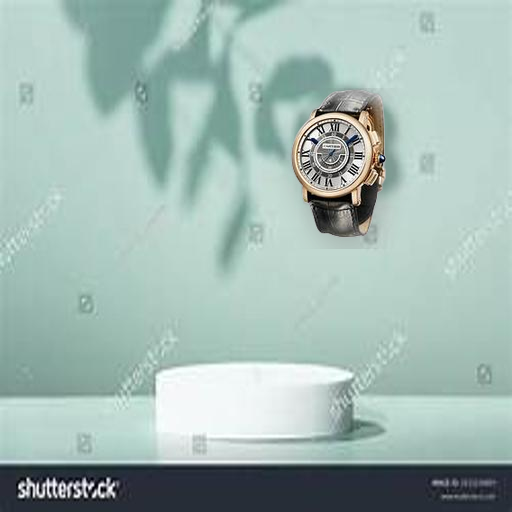

🎯 SUCCESS: Product placed on rendered_platform platform!


In [ ]:
#version 4

from PIL import Image, ImageDraw, ImageStat, ImageFilter, ImageEnhance
import numpy as np
import cv2
import random
from rembg import remove
from IPython.display import display
import torch
from scipy import ndimage
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

class PlatformSurfaceDetector:
    def __init__(self):
        self.model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

    def detect_rendered_platforms(self, image):
        """Specialized detection for 3D rendered platforms like in your image"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        h, w = cv_image.shape[:2]

        print("🔍 Analyzing image for 3D rendered platforms...")

        # Method 1: Detect white/light colored circular regions (platform tops)
        platforms = []

        # Create mask for light colors (white/light gray platforms)
        hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

        # White platform detection - broader range
        lower_white = np.array([0, 0, 180])    # Very light colors
        upper_white = np.array([180, 30, 255])  # Including slight tints
        white_mask = cv2.inRange(hsv, lower_white, upper_white)

        print(f"📊 White regions detected: {np.sum(white_mask > 0)} pixels")

        # Find contours in white regions
        contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)
            print(f"   Contour area: {area}")

            if area > 800:  # Lowered threshold
                # Get bounding rectangle
                x, y, w_rect, h_rect = cv2.boundingRect(contour)

                # Check if it's roughly circular/elliptical (platform top)
                aspect_ratio = w_rect / h_rect
                if 0.7 < aspect_ratio < 1.4:  # More lenient for elliptical shapes
                    # Try to fit a circle/ellipse
                    if len(contour) >= 5:
                        ellipse = cv2.fitEllipse(contour)
                        center = (int(ellipse[0][0]), int(ellipse[0][1]))
                        axes = (int(ellipse[1][0]/2), int(ellipse[1][1]/2))

                        platforms.append({
                            'center': center,
                            'axes': axes,
                            'bbox': (x, y, x + w_rect, y + h_rect),
                            'type': 'rendered_platform',
                            'area': area,
                            'contour': contour
                        })
                        print(f"✅ Found platform at {center} with size {axes}")

        # Method 2: Edge-based circular detection with relaxed parameters
        blurred = cv2.GaussianBlur(gray, (5, 5), 1)
        circles = cv2.HoughCircles(
            blurred,
            cv2.HOUGH_GRADIENT,
            dp=1,
            minDist=30,      # Reduced minimum distance
            param1=30,       # Reduced edge threshold
            param2=20,       # Reduced accumulator threshold
            minRadius=15,    # Smaller minimum radius
            maxRadius=min(w, h) // 3  # Larger maximum radius
        )

        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            print(f"🔵 HoughCircles found {len(circles)} circles")

            for (x, y, r) in circles:
                # Validate this circle represents a platform
                if self.validate_rendered_platform(cv_image, x, y, r):
                    platforms.append({
                        'center': (x, y),
                        'radius': r,
                        'bbox': (x-r, y-r, x+r, y+r),
                        'type': 'circular_platform',
                        'area': np.pi * r * r
                    })
                    print(f"✅ Validated circular platform at ({x}, {y}) radius {r}")

        # Method 3: Template matching for common platform shapes
        template_platforms = self.detect_by_brightness_patterns(cv_image)
        platforms.extend(template_platforms)

        return platforms

    def validate_rendered_platform(self, image, center_x, center_y, radius):
        """Validate if detected circle is a rendered platform - more lenient"""
        h, w = image.shape[:2]

        # Check bounds with padding
        if (center_x - radius < 0 or center_x + radius >= w or
            center_y - radius < 0 or center_y + radius >= h):
            return False

        # Extract region around the circle
        roi = image[max(0, center_y-radius):min(h, center_y+radius),
                   max(0, center_x-radius):min(w, center_x+radius)]

        if roi.size == 0:
            return False

        # Check if the region has platform-like characteristics
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # Platform should be relatively bright (white/light gray)
        mean_brightness = np.mean(roi_gray)

        # More lenient brightness check
        if mean_brightness > 120:  # Lowered from 150
            # Check for low variance (uniform surface)
            variance = np.var(roi_gray)
            if variance < 2000:  # Increased tolerance
                print(f"   Platform validated - brightness: {mean_brightness:.1f}, variance: {variance:.1f}")
                return True

        return False

    def detect_by_brightness_patterns(self, cv_image):
        """Detect platforms by analyzing brightness patterns"""
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

        # Find the brightest regions (likely platform tops)
        bright_threshold = np.percentile(gray, 85)  # Top 15% brightest pixels
        bright_mask = gray > bright_threshold

        # Find connected components in bright regions
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            bright_mask.astype(np.uint8), connectivity=8
        )

        platforms = []
        for i in range(1, num_labels):  # Skip background (label 0)
            area = stats[i, cv2.CC_STAT_AREA]
            if area > 500:  # Minimum area
                x = stats[i, cv2.CC_STAT_LEFT]
                y = stats[i, cv2.CC_STAT_TOP]
                w = stats[i, cv2.CC_STAT_WIDTH]
                h = stats[i, cv2.CC_STAT_HEIGHT]

                # Check aspect ratio for platform-like shapes
                aspect_ratio = w / h
                if 0.5 < aspect_ratio < 2.0:
                    center_x = int(centroids[i][0])
                    center_y = int(centroids[i][1])

                    platforms.append({
                        'center': (center_x, center_y),
                        'bbox': (x, y, x + w, y + h),
                        'type': 'brightness_platform',
                        'area': area,
                        'aspect_ratio': aspect_ratio
                    })
                    print(f"✅ Brightness-based platform found at ({center_x}, {center_y})")

        return platforms

    def find_best_platform_placement(self, platforms, product_size, image_size):
        """Find best platform with more lenient scoring"""
        if not platforms:
            return None

        print(f"🎯 Evaluating {len(platforms)} platforms for placement...")

        best_platform = None
        best_score = -1

        img_width, img_height = image_size
        product_width, product_height = product_size

        for i, platform in enumerate(platforms):
            score = 0

            # Basic size compatibility - more lenient
            if platform['type'] == 'circular_platform':
                radius = platform.get('radius', 50)
                if product_width < radius * 2.5 and product_height < radius * 2.5:  # More lenient
                    score += 1.5
            else:
                x1, y1, x2, y2 = platform['bbox']
                platform_width = x2 - x1
                platform_height = y2 - y1

                if (product_width < platform_width * 1.2 and
                    product_height < platform_height * 1.2):  # More lenient
                    score += 1.5

            # Position scoring
            center_x, center_y = platform['center']

            # Prefer platforms in reasonable positions
            if 0.2 * img_height < center_y < 0.8 * img_height:
                score += 1.0

            # Size bonus
            area = platform.get('area', 0)
            if area > 1000:
                score += 0.5

            # Type bonus for more reliable detection methods
            if platform['type'] in ['rendered_platform', 'circular_platform']:
                score += 0.8
            elif platform['type'] == 'brightness_platform':
                score += 0.6

            print(f"   Platform {i+1} ({platform['type']}): score = {score:.2f}")

            if score > best_score:
                best_score = score
                best_platform = platform

        print(f"🏆 Selected platform with score: {best_score:.2f}")
        return best_platform

    def calculate_product_position_on_platform(self, platform, product_size, image_size):
        """Calculate product position on platform"""
        product_width, product_height = product_size
        center_x, center_y = platform['center']

        # Center the product on the platform
        x = center_x - product_width // 2
        y = center_y - product_height // 2

        # Ensure within image bounds
        img_width, img_height = image_size
        x = max(0, min(x, img_width - product_width))
        y = max(0, min(y, img_height - product_height))

        return (int(x), int(y))

    def create_platform_aware_shadow(self, product_image, platform, product_position):
        """Create appropriate shadow for the platform"""
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]

        # Shadow parameters based on platform type
        if platform['type'] == 'circular_platform':
            blur_radius = 15
            opacity = 0.25
            offset_x, offset_y = 4, 6
        elif platform['type'] == 'rendered_platform':
            blur_radius = 12
            opacity = 0.3
            offset_x, offset_y = 3, 5
        else:
            blur_radius = 10
            opacity = 0.35
            offset_x, offset_y = 5, 7

        # Create shadow
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()

        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return shadow, (offset_x, offset_y)

    def process_with_platform_detection(self, product_path, background_path, scale_factor=0.9):
        """Main processing function"""
        print("🚀 Starting platform detection process...")

        # Load product
        product_with_bg = Image.open(product_path).convert("RGB")
        product_no_bg = remove(product_with_bg)

        # Resize product
        new_width = int(product_no_bg.width * scale_factor)
        new_height = int(product_no_bg.height * scale_factor)
        product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)
        print(f"📏 Product resized to: {new_width}x{new_height}")

        # Load background
        background_image = Image.open(background_path).convert("RGBA")
        print(f"🖼️ Background size: {background_image.size}")

        # Detect platforms with specialized method
        detected_platforms = self.detect_rendered_platforms(background_image)
        print(f"📊 Total platforms detected: {len(detected_platforms)}")

        # Find best platform
        best_platform = self.find_best_platform_placement(
            detected_platforms, product_no_bg.size, background_image.size
        )

        if best_platform:
            print(f"✅ Selected {best_platform['type']} platform at {best_platform['center']}")

            # Calculate position
            product_position = self.calculate_product_position_on_platform(
                best_platform, product_no_bg.size, background_image.size
            )

            # Create shadow
            product_shadow, shadow_offset = self.create_platform_aware_shadow(
                product_no_bg, best_platform, product_position
            )

        else:
            print("⚠️ No suitable platform found, using center placement")
            product_position = (
                (background_image.width - product_no_bg.width) // 2,
                (background_image.height - product_no_bg.height) // 2
            )

            # Basic shadow
            shadow = Image.new("RGBA", product_no_bg.size, (0, 0, 0, 0))
            mask = product_no_bg.split()[3]
            shadow_pixels = shadow.load()
            mask_pixels = mask.load()
            for y in range(shadow.height):
                for x in range(shadow.width):
                    if mask_pixels[x, y] > 0:
                        shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * 0.4))
            product_shadow = shadow.filter(ImageFilter.GaussianBlur(radius=10))
            shadow_offset = (5, 5)

        # Composite final image
        final_image = background_image.copy()

        # Add shadow
        shadow_position = (
            product_position[0] + shadow_offset[0],
            product_position[1] + shadow_offset[1]
        )
        final_image.paste(product_shadow, shadow_position, product_shadow)

        # Add product
        final_image.paste(product_no_bg, product_position, product_no_bg)

        print(f"🎨 Final placement at: {product_position}")

        return final_image, detected_platforms, best_platform

# Usage:
detector = PlatformSurfaceDetector()
final_image, detected_platforms, selected_platform = detector.process_with_platform_detection(
    "/content/watch2.jpg",
    "/content/bg12_new.jpg"
)

final_image.save("/content/platform_placement_result.png")
display(final_image)

if selected_platform:
    print(f"🎯 SUCCESS: Product placed on {selected_platform['type']} platform!")
else:
    print("❌ No platform detected - check detection parameters")

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-8-21 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


🚀 Starting platform detection process...
📏 Product resized to: 144x161
🖼️ Background size: (512, 512)
🔍 Analyzing image for 3D rendered platforms...
📊 White regions detected: 42 pixels
   white contour area: 21.0
   white contour area: 0.0
📊 Green regions detected: 102598 pixels
   green contour area: 0.0
   green contour area: 0.0
   green contour area: 7.0
   green contour area: 3623.0
   green contour area: 11.5
   green contour area: 9.0
   green contour area: 1.5
   green contour area: 0.0
   green contour area: 1.0
   green contour area: 3.5
   green contour area: 2.5
   green contour area: 35.5
   green contour area: 56.0
   green contour area: 492.5
   green contour area: 107.5
   green contour area: 997.5
✅ Found green platform at (23, 413) with size (20, 26)
   green contour area: 55.5
   green contour area: 5.5
   green contour area: 45.0
   green contour area: 1.0
   green contour area: 14.0
   green contour area: 0.0
   green contour area: 413.5
   green contour area: 0.0


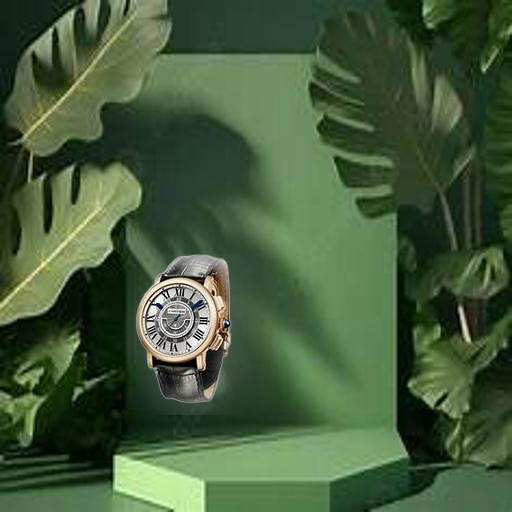

🎯 SUCCESS: Product placed on circular_platform platform!


In [ ]:
#version 4 - Multi-Color Platform Detection

from PIL import Image, ImageDraw, ImageStat, ImageFilter, ImageEnhance
import numpy as np
import cv2
import random
from rembg import remove
from IPython.display import display
import torch
from scipy import ndimage
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

class PlatformSurfaceDetector:
    def __init__(self):
        self.model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

    def detect_rendered_platforms(self, image):
        """Specialized detection for 3D rendered platforms - now supports multiple colors"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        h, w = cv_image.shape[:2]

        print("🔍 Analyzing image for 3D rendered platforms...")

        platforms = []
        hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

        # MAIN FIX: Multiple color ranges for different platform types
        color_ranges = {
            'white': ([0, 0, 180], [180, 30, 255]),      # White/light gray (original)
            'green': ([35, 40, 100], [85, 255, 255]),    # Green platforms
            'blue': ([100, 50, 100], [130, 255, 255]),   # Blue platforms
            'brown': ([8, 50, 80], [25, 255, 200]),      # Wood/brown platforms
            'gray': ([0, 0, 60], [180, 50, 180]),        # Medium gray platforms
            'cream': ([15, 20, 150], [35, 80, 255]),     # Cream/beige platforms
            'pink': ([140, 30, 150], [170, 100, 255])    # Pink/rose platforms
        }

        # Method 1: Multi-color platform detection
        for color_name, (lower, upper) in color_ranges.items():
            lower = np.array(lower)
            upper = np.array(upper)
            color_mask = cv2.inRange(hsv, lower, upper)

            print(f"📊 {color_name.capitalize()} regions detected: {np.sum(color_mask > 0)} pixels")

            # Find contours in colored regions
            contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                area = cv2.contourArea(contour)
                print(f"   {color_name} contour area: {area}")

                if area > 800:  # Same threshold
                    # Get bounding rectangle
                    x, y, w_rect, h_rect = cv2.boundingRect(contour)

                    # Check if it's roughly circular/elliptical (platform top)
                    aspect_ratio = w_rect / h_rect
                    if 0.7 < aspect_ratio < 1.4:  # Same aspect ratio check
                        # Try to fit a circle/ellipse
                        if len(contour) >= 5:
                            ellipse = cv2.fitEllipse(contour)
                            center = (int(ellipse[0][0]), int(ellipse[0][1]))
                            axes = (int(ellipse[1][0]/2), int(ellipse[1][1]/2))

                            platforms.append({
                                'center': center,
                                'axes': axes,
                                'bbox': (x, y, x + w_rect, y + h_rect),
                                'type': f'rendered_platform_{color_name}',
                                'area': area,
                                'contour': contour,
                                'color': color_name
                            })
                            print(f"✅ Found {color_name} platform at {center} with size {axes}")

        # Method 2: Edge-based circular detection (unchanged - works for any color)
        blurred = cv2.GaussianBlur(gray, (5, 5), 1)
        circles = cv2.HoughCircles(
            blurred,
            cv2.HOUGH_GRADIENT,
            dp=1,
            minDist=30,
            param1=30,
            param2=20,
            minRadius=15,
            maxRadius=min(w, h) // 3
        )

        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            print(f"🔵 HoughCircles found {len(circles)} circles")

            for (x, y, r) in circles:
                # Use improved validation that works for any color
                if self.validate_rendered_platform_improved(cv_image, x, y, r):
                    platforms.append({
                        'center': (x, y),
                        'radius': r,
                        'bbox': (x-r, y-r, x+r, y+r),
                        'type': 'circular_platform',
                        'area': np.pi * r * r
                    })
                    print(f"✅ Validated circular platform at ({x}, {y}) radius {r}")

        # Method 3: Enhanced brightness patterns (works for any color)
        template_platforms = self.detect_by_brightness_patterns_improved(cv_image)
        platforms.extend(template_platforms)

        return platforms

    def validate_rendered_platform_improved(self, image, center_x, center_y, radius):
        """Improved validation that works for any color platform"""
        h, w = image.shape[:2]

        # Check bounds with padding
        if (center_x - radius < 0 or center_x + radius >= w or
            center_y - radius < 0 or center_y + radius >= h):
            return False

        # Extract region around the circle
        roi = image[max(0, center_y-radius):min(h, center_y+radius),
                   max(0, center_x-radius):min(w, center_x+radius)]

        if roi.size == 0:
            return False

        # IMPROVED: Check for uniform texture/color instead of just brightness
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # Check uniformity (low variance = platform-like surface)
        variance = np.var(roi_gray)
        if variance < 2000:  # Uniform surface

            # Additional check: region should be distinct from surroundings
            # Sample surrounding area
            padding = radius // 2
            surround_roi = image[max(0, center_y-radius-padding):min(h, center_y+radius+padding),
                               max(0, center_x-radius-padding):min(w, center_x+radius+padding)]

            if surround_roi.size > 0:
                surround_gray = cv2.cvtColor(surround_roi, cv2.COLOR_BGR2GRAY)
                roi_mean = np.mean(roi_gray)
                surround_mean = np.mean(surround_gray)

                # Platform should be somewhat different from surroundings
                if abs(roi_mean - surround_mean) > 15:  # Some contrast
                    print(f"   Platform validated - variance: {variance:.1f}, contrast: {abs(roi_mean - surround_mean):.1f}")
                    return True

        return False

    def detect_by_brightness_patterns_improved(self, cv_image):
        """Improved brightness pattern detection for any color"""
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        platforms = []

        # IMPROVEMENT: Use multiple brightness percentiles, not just brightest
        percentiles = [85, 75, 65, 35, 25, 15]  # Check bright, medium, and dark regions

        for percentile in percentiles:
            if percentile > 50:
                # Bright regions
                threshold = np.percentile(gray, percentile)
                mask = gray > threshold
                region_type = f'bright_{percentile}'
            else:
                # Dark regions (might be darker platforms)
                threshold = np.percentile(gray, percentile)
                mask = gray < threshold
                region_type = f'dark_{percentile}'

            # Find connected components
            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
                mask.astype(np.uint8), connectivity=8
            )

            for i in range(1, num_labels):  # Skip background (label 0)
                area = stats[i, cv2.CC_STAT_AREA]
                if area > 500:
                    x = stats[i, cv2.CC_STAT_LEFT]
                    y = stats[i, cv2.CC_STAT_TOP]
                    w = stats[i, cv2.CC_STAT_WIDTH]
                    h = stats[i, cv2.CC_STAT_HEIGHT]

                    # Check aspect ratio for platform-like shapes
                    aspect_ratio = w / h
                    if 0.5 < aspect_ratio < 2.0:
                        center_x = int(centroids[i][0])
                        center_y = int(centroids[i][1])

                        # Additional validation: check if region is uniform
                        roi = gray[y:y+h, x:x+w]
                        if roi.size > 0 and np.var(roi) < 1500:  # Uniform region
                            platforms.append({
                                'center': (center_x, center_y),
                                'bbox': (x, y, x + w, y + h),
                                'type': f'brightness_platform_{region_type}',
                                'area': area,
                                'aspect_ratio': aspect_ratio
                            })
                            print(f"✅ {region_type} platform found at ({center_x}, {center_y})")

        return platforms

    def find_best_platform_placement(self, platforms, product_size, image_size):
        """Find best platform with improved scoring for any color"""
        if not platforms:
            return None

        print(f"🎯 Evaluating {len(platforms)} platforms for placement...")

        best_platform = None
        best_score = -1

        img_width, img_height = image_size
        product_width, product_height = product_size

        for i, platform in enumerate(platforms):
            score = 0

            # Basic size compatibility - more lenient
            if platform['type'] == 'circular_platform':
                radius = platform.get('radius', 50)
                if product_width < radius * 2.5 and product_height < radius * 2.5:
                    score += 1.5
            else:
                x1, y1, x2, y2 = platform['bbox']
                platform_width = x2 - x1
                platform_height = y2 - y1

                if (product_width < platform_width * 1.2 and
                    product_height < platform_height * 1.2):
                    score += 1.5

            # Position scoring
            center_x, center_y = platform['center']

            # Prefer platforms in reasonable positions
            if 0.2 * img_height < center_y < 0.8 * img_height:
                score += 1.0

            # Size bonus
            area = platform.get('area', 0)
            if area > 1000:
                score += 0.5

            # IMPROVED: Type bonus for different detection methods
            platform_type = platform['type']
            if 'rendered_platform' in platform_type:
                score += 0.8  # Color-based detection is reliable
            elif platform_type == 'circular_platform':
                score += 0.9  # Circular detection is very reliable
            elif 'brightness_platform_bright' in platform_type:
                score += 0.7  # Bright regions are good
            elif 'brightness_platform_dark' in platform_type:
                score += 0.5  # Dark regions are less reliable but possible

            print(f"   Platform {i+1} ({platform['type']}): score = {score:.2f}")

            if score > best_score:
                best_score = score
                best_platform = platform

        print(f"🏆 Selected platform with score: {best_score:.2f}")
        return best_platform

    def calculate_product_position_on_platform(self, platform, product_size, image_size):
        """Calculate product position on platform"""
        product_width, product_height = product_size
        center_x, center_y = platform['center']

        # Center the product on the platform
        x = center_x - product_width // 2
        y = center_y - product_height // 2

        # Ensure within image bounds
        img_width, img_height = image_size
        x = max(0, min(x, img_width - product_width))
        y = max(0, min(y, img_height - product_height))

        return (int(x), int(y))

    def create_platform_aware_shadow(self, product_image, platform, product_position):
        """Create appropriate shadow for the platform"""
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]

        # Shadow parameters based on platform type
        if platform['type'] == 'circular_platform':
            blur_radius = 15
            opacity = 0.25
            offset_x, offset_y = 4, 6
        elif 'rendered_platform' in platform['type']:
            blur_radius = 12
            opacity = 0.3
            offset_x, offset_y = 3, 5
        else:
            blur_radius = 10
            opacity = 0.35
            offset_x, offset_y = 5, 7

        # Create shadow
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()

        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return shadow, (offset_x, offset_y)

    def process_with_platform_detection(self, product_path, background_path, scale_factor=0.9):
        """Main processing function"""
        print("🚀 Starting platform detection process...")

        # Load product
        product_with_bg = Image.open(product_path).convert("RGB")
        product_no_bg = remove(product_with_bg)

        # Resize product
        new_width = int(product_no_bg.width * scale_factor)
        new_height = int(product_no_bg.height * scale_factor)
        product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)
        print(f"📏 Product resized to: {new_width}x{new_height}")

        # Load background
        background_image = Image.open(background_path).convert("RGBA")
        print(f"🖼️ Background size: {background_image.size}")

        # Detect platforms with specialized method
        detected_platforms = self.detect_rendered_platforms(background_image)
        print(f"📊 Total platforms detected: {len(detected_platforms)}")

        # Find best platform
        best_platform = self.find_best_platform_placement(
            detected_platforms, product_no_bg.size, background_image.size
        )

        if best_platform:
            print(f"✅ Selected {best_platform['type']} platform at {best_platform['center']}")

            # Calculate position
            product_position = self.calculate_product_position_on_platform(
                best_platform, product_no_bg.size, background_image.size
            )

            # Create shadow
            product_shadow, shadow_offset = self.create_platform_aware_shadow(
                product_no_bg, best_platform, product_position
            )

        else:
            print("⚠️ No suitable platform found, using center placement")
            product_position = (
                (background_image.width - product_no_bg.width) // 2,
                (background_image.height - product_no_bg.height) // 2
            )

            # Basic shadow
            shadow = Image.new("RGBA", product_no_bg.size, (0, 0, 0, 0))
            mask = product_no_bg.split()[3]
            shadow_pixels = shadow.load()
            mask_pixels = mask.load()
            for y in range(shadow.height):
                for x in range(shadow.width):
                    if mask_pixels[x, y] > 0:
                        shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * 0.4))
            product_shadow = shadow.filter(ImageFilter.GaussianBlur(radius=10))
            shadow_offset = (5, 5)

        # Composite final image
        final_image = background_image.copy()

        # Add shadow
        shadow_position = (
            product_position[0] + shadow_offset[0],
            product_position[1] + shadow_offset[1]
        )
        final_image.paste(product_shadow, shadow_position, product_shadow)

        # Add product
        final_image.paste(product_no_bg, product_position, product_no_bg)

        print(f"🎨 Final placement at: {product_position}")

        return final_image, detected_platforms, best_platform

# Usage:
detector = PlatformSurfaceDetector()
final_image, detected_platforms, selected_platform = detector.process_with_platform_detection(
    "/content/watch2.jpg",
    "/content/bg11_new.jpg"
)

final_image.save("/content/platform_placement_result.png")
display(final_image)

if selected_platform:
    print(f"🎯 SUCCESS: Product placed on {selected_platform['type']} platform!")
else:
    print("❌ No platform detected - check detection parameters")

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-8-21 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


🚀 Starting comprehensive surface detection...
📏 Product resized to: 144x161
🖼️ Background size: (512, 512)
🔍 Starting comprehensive surface analysis...
🔵 Found 49 circular surfaces
⬛ Found 0 rectangular surfaces
📏 Found 0 line-based surfaces
🎨 Found 6 color-uniform surfaces
📈 Found 1 gradient-based surfaces
🧠 Found 0 semantic surfaces
📊 Total surfaces detected: 56
🎯 Evaluating 56 surfaces for placement...
   Surface 1 (circular): score = 3.52
   Surface 2 (circular): score = 3.46
   Surface 3 (circular): score = 3.42
   Surface 4 (circular): score = 3.17
   Surface 5 (circular): score = 3.56
   Surface 6 (circular): score = 3.42
   Surface 7 (circular): score = 3.21
   Surface 8 (circular): score = 3.31
   Surface 9 (circular): score = 3.48
   Surface 10 (circular): score = 2.96
   Surface 11 (circular): score = 3.10
   Surface 12 (circular): score = 3.24
   Surface 13 (circular): score = 3.33
   Surface 14 (circular): score = 3.16
   Surface 15 (circular): score = 3.04
   Surface 16 (

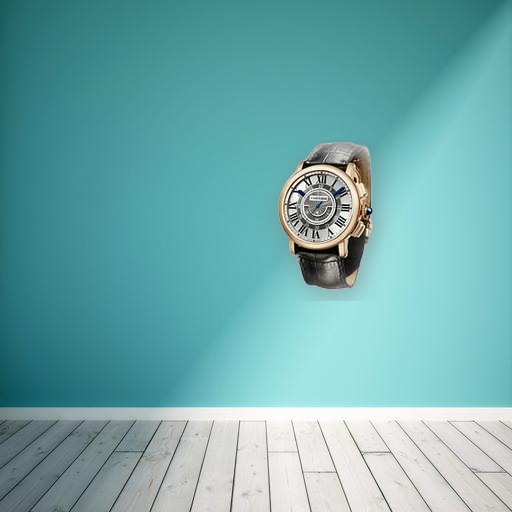

🎯 SUCCESS: Product placed on color_uniform surface!
📍 Surface details: {'type': 'color_uniform', 'bbox': (141, 23, 512, 407), 'center': (326, 215), 'color_space': 'BGR', 'confidence': 0.8, 'area': 55425.0, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512), dtype=uint8)}


In [ ]:
### have to work on this ----extended version of the prev but not working very well rn


from PIL import Image, ImageDraw, ImageStat, ImageFilter, ImageEnhance
import numpy as np
import cv2
import random
from rembg import remove
from IPython.display import display
import torch
from scipy import ndimage
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

class GenericSurfaceDetector:
    def __init__(self):
        self.model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

    def detect_all_surface_types(self, image):
        """Comprehensive surface detection using multiple methods"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        h, w = cv_image.shape[:2]

        print("🔍 Starting comprehensive surface analysis...")

        all_surfaces = []

        # Method 1: Circular platform detection (pedestals, round tables)
        circular_surfaces = self.detect_circular_surfaces(cv_image, gray)
        all_surfaces.extend(circular_surfaces)
        print(f"🔵 Found {len(circular_surfaces)} circular surfaces")

        # Method 2: Rectangular surface detection (tables, shelves, platforms)
        rectangular_surfaces = self.detect_rectangular_surfaces(cv_image, gray)
        all_surfaces.extend(rectangular_surfaces)
        print(f"⬛ Found {len(rectangular_surfaces)} rectangular surfaces")

        # Method 3: Line-based surface detection (floors, table edges)
        line_surfaces = self.detect_line_based_surfaces(cv_image, gray)
        all_surfaces.extend(line_surfaces)
        print(f"📏 Found {len(line_surfaces)} line-based surfaces")

        # Method 4: Color uniformity surfaces (any flat colored area)
        color_surfaces = self.detect_color_uniform_surfaces(cv_image)
        all_surfaces.extend(color_surfaces)
        print(f"🎨 Found {len(color_surfaces)} color-uniform surfaces")

        # Method 5: Gradient-based flat surfaces
        gradient_surfaces = self.detect_gradient_surfaces(gray)
        all_surfaces.extend(gradient_surfaces)
        print(f"📈 Found {len(gradient_surfaces)} gradient-based surfaces")

        # Method 6: Semantic surface detection (ground, table, etc.)
        semantic_surfaces = self.detect_semantic_surfaces(cv_image)
        all_surfaces.extend(semantic_surfaces)
        print(f"🧠 Found {len(semantic_surfaces)} semantic surfaces")

        return all_surfaces

    def detect_circular_surfaces(self, cv_image, gray):
        """Detect circular platforms, pedestals, round tables"""
        surfaces = []

        # Multiple circle detection approaches
        blur_levels = [(5, 1), (9, 2), (15, 3)]

        for blur_size, sigma in blur_levels:
            blurred = cv2.GaussianBlur(gray, (blur_size, blur_size), sigma)

            circles = cv2.HoughCircles(
                blurred,
                cv2.HOUGH_GRADIENT,
                dp=1,
                minDist=20,
                param1=50,
                param2=25,
                minRadius=10,
                maxRadius=min(cv_image.shape[:2]) // 2
            )

            if circles is not None:
                circles = np.round(circles[0, :]).astype("int")
                for (x, y, r) in circles:
                    if self.validate_circular_surface(cv_image, x, y, r):
                        surfaces.append({
                            'type': 'circular',
                            'center': (x, y),
                            'radius': r,
                            'bbox': (x-r, y-r, x+r, y+r),
                            'confidence': self.calculate_surface_confidence(cv_image, x-r, y-r, x+r, y+r),
                            'area': np.pi * r * r
                        })

        return surfaces

    def detect_rectangular_surfaces(self, cv_image, gray):
        """Detect rectangular surfaces like tables, platforms, shelves"""
        surfaces = []

        # Edge detection with multiple thresholds
        for low_thresh, high_thresh in [(30, 100), (50, 150), (70, 200)]:
            edges = cv2.Canny(gray, low_thresh, high_thresh)

            # Find contours
            contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                area = cv2.contourArea(contour)
                if area > 500:  # Minimum area threshold
                    # Approximate to polygon
                    epsilon = 0.02 * cv2.arcLength(contour, True)
                    approx = cv2.approxPolyDP(contour, epsilon, True)

                    # Check for rectangular shapes (4-8 sides for flexibility)
                    if 4 <= len(approx) <= 8:
                        x, y, w, h = cv2.boundingRect(contour)
                        aspect_ratio = w / h

                        # Valid aspect ratios for surfaces
                        if 0.2 < aspect_ratio < 5.0:
                            surfaces.append({
                                'type': 'rectangular',
                                'bbox': (x, y, x+w, y+h),
                                'center': (x + w//2, y + h//2),
                                'contour': approx,
                                'confidence': self.calculate_surface_confidence(cv_image, x, y, x+w, y+h),
                                'area': area,
                                'aspect_ratio': aspect_ratio
                            })

        return surfaces

    def detect_line_based_surfaces(self, cv_image, gray):
        """Detect surfaces based on line patterns (floors, table edges)"""
        surfaces = []

        # Detect lines
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                               minLineLength=50, maxLineGap=10)

        if lines is None:
            return surfaces

        # Separate horizontal and vertical lines
        horizontal_lines = []
        vertical_lines = []

        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = np.abs(np.arctan2(y2-y1, x2-x1) * 180 / np.pi)

            if angle < 20 or angle > 160:  # Horizontal lines
                horizontal_lines.append(line)
            elif 70 < angle < 110:  # Vertical lines
                vertical_lines.append(line)

        # Create surfaces from horizontal lines (potential floor/table surfaces)
        surfaces.extend(self.extract_surface_from_lines(horizontal_lines, cv_image.shape, 'horizontal'))

        return surfaces

    def extract_surface_from_lines(self, lines, image_shape, orientation):
        """Extract surface areas from detected lines"""
        if not lines:
            return []

        surfaces = []
        h, w = image_shape[:2]

        # Group lines by position
        line_positions = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if orientation == 'horizontal':
                mid_y = (y1 + y2) / 2
                line_positions.append((mid_y, line))
            else:
                mid_x = (x1 + x2) / 2
                line_positions.append((mid_x, line))

        # Fix the sorting issue
        line_positions.sort(key=lambda x: x[0])

        # Find surfaces between parallel lines
        for i in range(len(line_positions) - 1):
            pos1, line1 = line_positions[i]
            pos2, line2 = line_positions[i + 1]

            if orientation == 'horizontal':
                if pos2 - pos1 > 20:  # Minimum surface height
                    x1_1, y1_1, x2_1, y2_1 = line1[0]
                    x1_2, y1_2, x2_2, y2_2 = line2[0]

                    # Create surface rectangle
                    x_min = min(x1_1, x2_1, x1_2, x2_2)
                    x_max = max(x1_1, x2_1, x1_2, x2_2)
                    y_min = min(pos1, pos2)
                    y_max = max(pos1, pos2)

                    surfaces.append({
                        'type': 'line_based',
                        'bbox': (int(x_min), int(y_min), int(x_max), int(y_max)),
                        'center': (int((x_min + x_max) / 2), int((y_min + y_max) / 2)),
                        'orientation': orientation,
                        'confidence': 0.6,
                        'area': (x_max - x_min) * (y_max - y_min)
                    })

        return surfaces

    def detect_color_uniform_surfaces(self, cv_image):
        """Detect surfaces based on color uniformity"""
        surfaces = []

        # Convert to different color spaces for better segmentation
        hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)
        lab = cv2.cvtColor(cv_image, cv2.COLOR_BGR2LAB)

        # Find uniform colored regions
        for color_space, image_cs in [('BGR', cv_image), ('HSV', hsv), ('LAB', lab)]:
            # K-means clustering to find dominant colors
            pixels = image_cs.reshape(-1, 3)
            kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
            labels = kmeans.fit_predict(pixels)

            # Reshape back
            segmented = labels.reshape(image_cs.shape[:2])

            # Find largest uniform regions
            unique_labels, counts = np.unique(labels, return_counts=True)
            largest_segments = unique_labels[np.argsort(counts)[-4:]]  # Top 4 segments

            for label in largest_segments:
                mask = (segmented == label).astype(np.uint8) * 255

                # Find contours in this color segment
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                for contour in contours:
                    area = cv2.contourArea(contour)
                    if area > 800:  # Minimum area
                        x, y, w, h = cv2.boundingRect(contour)

                        # Check if it's a reasonable surface shape
                        aspect_ratio = w / h
                        if 0.1 < aspect_ratio < 10:
                            surfaces.append({
                                'type': 'color_uniform',
                                'bbox': (x, y, x+w, y+h),
                                'center': (x + w//2, y + h//2),
                                'color_space': color_space,
                                'confidence': min(0.8, area / 5000),
                                'area': area,
                                'mask': mask
                            })

        # Remove duplicates based on overlap
        surfaces = self.remove_duplicate_surfaces(surfaces)
        return surfaces[:10]  # Limit to top 10

    def detect_gradient_surfaces(self, gray):
        """Detect flat surfaces based on low gradient (texture analysis)"""
        surfaces = []

        # Calculate gradients
        grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

        # Normalize
        gradient_norm = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Find low gradient areas (flat surfaces)
        low_gradient = gradient_norm < 30  # Very low gradient threshold

        # Clean up the mask
        kernel = np.ones((5,5), np.uint8)
        low_gradient = cv2.morphologyEx(low_gradient.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        low_gradient = cv2.morphologyEx(low_gradient, cv2.MORPH_OPEN, kernel)

        # Find contours
        contours, _ = cv2.findContours(low_gradient * 255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 1000:
                x, y, w, h = cv2.boundingRect(contour)
                surfaces.append({
                    'type': 'gradient_flat',
                    'bbox': (x, y, x+w, y+h),
                    'center': (x + w//2, y + h//2),
                    'confidence': min(0.7, area / 3000),
                    'area': area
                })

        return surfaces

    def detect_semantic_surfaces(self, cv_image):
        """Detect surfaces based on semantic understanding"""
        surfaces = []

        # Simple heuristic-based semantic detection
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        h, w = cv_image.shape[:2]

        # Bottom region analysis (likely floor/ground)
        bottom_region = gray[int(h*0.6):, :]
        if bottom_region.size > 0:
            # Check if bottom region is relatively uniform (floor-like)
            bottom_variance = np.var(bottom_region)
            if bottom_variance < 1500:  # Low variance suggests uniform surface
                surfaces.append({
                    'type': 'semantic_floor',
                    'bbox': (0, int(h*0.6), w, h),
                    'center': (w//2, int(h*0.8)),
                    'confidence': 0.5,
                    'area': w * int(h*0.4),
                    'semantic_label': 'floor'
                })

        # Middle region analysis (likely tables/platforms)
        middle_region = gray[int(h*0.3):int(h*0.7), :]
        if middle_region.size > 0:
            # Find horizontal structures in middle region
            edges = cv2.Canny(middle_region, 50, 150)
            lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                                   minLineLength=w//4, maxLineGap=20)

            if lines is not None and len(lines) > 2:  # Multiple horizontal lines suggest table/platform
                surfaces.append({
                    'type': 'semantic_table',
                    'bbox': (0, int(h*0.3), w, int(h*0.7)),
                    'center': (w//2, int(h*0.5)),
                    'confidence': 0.4,
                    'area': w * int(h*0.4),
                    'semantic_label': 'table'
                })

        return surfaces

    def validate_circular_surface(self, image, center_x, center_y, radius):
        """Validate if detected circle is a surface"""
        h, w = image.shape[:2]

        # Bounds check
        if (center_x - radius < 0 or center_x + radius >= w or
            center_y - radius < 0 or center_y + radius >= h):
            return False

        # Extract circular region
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, (center_x, center_y), radius, 255, -1)

        # Check color uniformity
        roi = cv2.bitwise_and(image, image, mask=mask)
        roi_pixels = roi[mask > 0]

        if len(roi_pixels) > 0:
            variance = np.var(roi_pixels)
            mean_brightness = np.mean(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)[mask > 0])

            # Surface validation criteria
            return (variance < 3000 and  # Not too textured
                   mean_brightness > 50 and  # Not too dark
                   radius > 15)  # Not too small

        return False

    def calculate_surface_confidence(self, image, x1, y1, x2, y2):
        """Calculate confidence score for a surface region"""
        roi = image[y1:y2, x1:x2]
        if roi.size == 0:
            return 0.0

        # Color uniformity
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        color_variance = np.var(roi_gray)
        uniformity_score = max(0, 1 - color_variance / 2000)

        # Size score
        area = (x2 - x1) * (y2 - y1)
        size_score = min(1.0, area / 5000)

        # Position score (prefer middle and lower regions)
        h = image.shape[0]
        center_y = (y1 + y2) / 2
        position_score = 1.0 if center_y > h * 0.3 else 0.5

        return (uniformity_score * 0.5 + size_score * 0.3 + position_score * 0.2)

    def remove_duplicate_surfaces(self, surfaces):
        """Remove overlapping duplicate surfaces"""
        if not surfaces:
            return surfaces

        # Sort by confidence
        surfaces.sort(key=lambda x: x.get('confidence', 0), reverse=True)

        filtered_surfaces = []
        for surface in surfaces:
            is_duplicate = False

            for existing in filtered_surfaces:
                if self.surfaces_overlap(surface, existing, threshold=0.5):
                    is_duplicate = True
                    break

            if not is_duplicate:
                filtered_surfaces.append(surface)

        return filtered_surfaces

    def surfaces_overlap(self, surf1, surf2, threshold=0.5):
        """Check if two surfaces overlap significantly"""
        bbox1 = surf1['bbox']
        bbox2 = surf2['bbox']

        x1_1, y1_1, x2_1, y2_1 = bbox1
        x1_2, y1_2, x2_2, y2_2 = bbox2

        # Calculate intersection
        x_left = max(x1_1, x1_2)
        y_top = max(y1_1, y1_2)
        x_right = min(x2_1, x2_2)
        y_bottom = min(y2_1, y2_2)

        if x_right <= x_left or y_bottom <= y_top:
            return False

        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
        area2 = (x2_2 - x1_2) * (y2_2 - y1_2)

        overlap_ratio = intersection_area / min(area1, area2)
        return overlap_ratio > threshold

    def score_surface_for_placement(self, surface, product_size, image_size):
        """Score how suitable a surface is for product placement"""
        score = 0.0

        product_width, product_height = product_size
        img_width, img_height = image_size

        # Base confidence score
        score += surface.get('confidence', 0.5) * 2.0

        # Size compatibility
        x1, y1, x2, y2 = surface['bbox']
        surface_width = x2 - x1
        surface_height = y2 - y1

        width_ratio = product_width / surface_width
        height_ratio = product_height / surface_height

        if width_ratio <= 0.8 and height_ratio <= 0.8:  # Product fits comfortably
            score += 1.5
        elif width_ratio <= 1.0 and height_ratio <= 1.0:  # Product barely fits
            score += 0.8

        # Surface type bonus
        type_bonuses = {
            'circular': 1.0,
            'rectangular': 0.9,
            'color_uniform': 0.7,
            'gradient_flat': 0.6,
            'line_based': 0.5,
            'semantic_floor': 0.4,
            'semantic_table': 0.8
        }
        score += type_bonuses.get(surface['type'], 0.3)

        # Position preference (middle and lower regions)
        center_x, center_y = surface['center']

        # Vertical position (prefer lower half)
        if center_y > img_height * 0.5:
            score += 0.5

        # Horizontal position (slight preference for center)
        horizontal_bias = 1 - abs(center_x - img_width/2) / (img_width/2)
        score += horizontal_bias * 0.3

        # Area bonus
        area = surface.get('area', 0)
        area_score = min(1.0, area / (img_width * img_height * 0.1))
        score += area_score * 0.4

        return max(0, score)

    def find_best_surface(self, surfaces, product_size, image_size):
        """Find the best surface for product placement"""
        if not surfaces:
            return None

        print(f"🎯 Evaluating {len(surfaces)} surfaces for placement...")

        scored_surfaces = []
        for i, surface in enumerate(surfaces):
            score = self.score_surface_for_placement(surface, product_size, image_size)
            scored_surfaces.append((score, surface))
            print(f"   Surface {i+1} ({surface['type']}): score = {score:.2f}")

        # Sort by score
        scored_surfaces.sort(key=lambda x: x[0], reverse=True)

        best_score, best_surface = scored_surfaces[0]
        print(f"🏆 Selected {best_surface['type']} surface with score: {best_score:.2f}")

        return best_surface if best_score > 1.0 else None

    def calculate_product_position(self, surface, product_size, image_size):
        """Calculate optimal product position on surface"""
        product_width, product_height = product_size
        img_width, img_height = image_size

        if surface['type'] == 'circular':
            # Center on circular surface
            center_x, center_y = surface['center']
            x = center_x - product_width // 2
            y = center_y - product_height // 2
        else:
            # Center on rectangular surface
            x1, y1, x2, y2 = surface['bbox']
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            x = center_x - product_width // 2
            y = center_y - product_height // 2

        # Ensure within image bounds
        x = max(0, min(x, img_width - product_width))
        y = max(0, min(y, img_height - product_height))

        return (int(x), int(y))

    def create_adaptive_shadow(self, product_image, surface, product_position):
        """Create shadow adapted to surface type"""
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]

        # Shadow parameters based on surface type
        shadow_params = {
            'circular': (15, 0.25, (4, 6)),
            'rectangular': (12, 0.3, (5, 7)),
            'color_uniform': (10, 0.35, (3, 5)),
            'gradient_flat': (8, 0.4, (4, 6)),
            'line_based': (10, 0.3, (5, 8)),
            'semantic_floor': (12, 0.4, (6, 10)),
            'semantic_table': (10, 0.3, (4, 6))
        }

        blur_radius, opacity, (offset_x, offset_y) = shadow_params.get(
            surface['type'], (10, 0.35, (5, 7))
        )

        # Create shadow
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()

        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return shadow, (offset_x, offset_y)

    def process_with_generic_detection(self, product_path, background_path, scale_factor=0.9):
        """Main processing function with comprehensive surface detection"""
        print("🚀 Starting comprehensive surface detection...")

        # Load and process product
        product_with_bg = Image.open(product_path).convert("RGB")
        product_no_bg = remove(product_with_bg)

        new_width = int(product_no_bg.width * scale_factor)
        new_height = int(product_no_bg.height * scale_factor)
        product_no_bg = product_no_bg.resize((new_width, new_height), Image.LANCZOS)
        print(f"📏 Product resized to: {new_width}x{new_height}")

        # Load background
        background_image = Image.open(background_path).convert("RGBA")
        print(f"🖼️ Background size: {background_image.size}")

        # Detect all types of surfaces
        all_surfaces = self.detect_all_surface_types(background_image)
        print(f"📊 Total surfaces detected: {len(all_surfaces)}")

        # Find best surface
        best_surface = self.find_best_surface(all_surfaces, product_no_bg.size, background_image.size)

        if best_surface:
            print(f"✅ Placing product on {best_surface['type']} surface")

            # Calculate position
            product_position = self.calculate_product_position(
                best_surface, product_no_bg.size, background_image.size
            )

            # Create adaptive shadow
            product_shadow, shadow_offset = self.create_adaptive_shadow(
                product_no_bg, best_surface, product_position
            )

        else:
            print("⚠️ No suitable surface found, using center placement")
            product_position = (
                (background_image.width - product_no_bg.width) // 2,
                (background_image.height - product_no_bg.height) // 2
            )

            # Basic shadow
            shadow = Image.new("RGBA", product_no_bg.size, (0, 0, 0, 0))
            mask = product_no_bg.split()[3]
            shadow_pixels = shadow.load()
            mask_pixels = mask.load()
            for y in range(shadow.height):
                for x in range(shadow.width):
                    if mask_pixels[x, y] > 0:
                        shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * 0.4))
            product_shadow = shadow.filter(ImageFilter.GaussianBlur(radius=10))
            shadow_offset = (5, 5)

        # Composite final image
        final_image = background_image.copy()

        # Add shadow
        shadow_position = (
            product_position[0] + shadow_offset[0],
            product_position[1] + shadow_offset[1]
        )
        final_image.paste(product_shadow, shadow_position, product_shadow)

        # Add product
        final_image.paste(product_no_bg, product_position, product_no_bg)

        print(f"🎨 Final placement at: {product_position}")

        return final_image, all_surfaces, best_surface

# Usage for ANY type of surface:
detector = GenericSurfaceDetector()
final_image, all_surfaces, selected_surface = detector.process_with_generic_detection(
    "/content/watch2.jpg",
    "/content/bg5_new.jpg"
)

final_image.save("/content/generic_surface_placement.png")
display(final_image)

if selected_surface:
    print(f"🎯 SUCCESS: Product placed on {selected_surface['type']} surface!")
    print(f"📍 Surface details: {selected_surface}")
else:
    print("❌ No suitable surface detected")



In [ ]:
import matplotlib.font_manager
print(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))


['/usr/share/fonts/truetype/liberation/LiberationSans-BoldItalic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', '/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf', '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-BoldItalic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf', '/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf', '/usr/share/fonts/truetype/liberation/LiberationSerif-BoldItalic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSans-Italic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Bold.ttf', '/usr/share/fonts/truetype/liberation/LiberationSerif-Italic.ttf', '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf', '/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf', '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf', '/usr/share/fonts/truetype/liberation/Liberatio

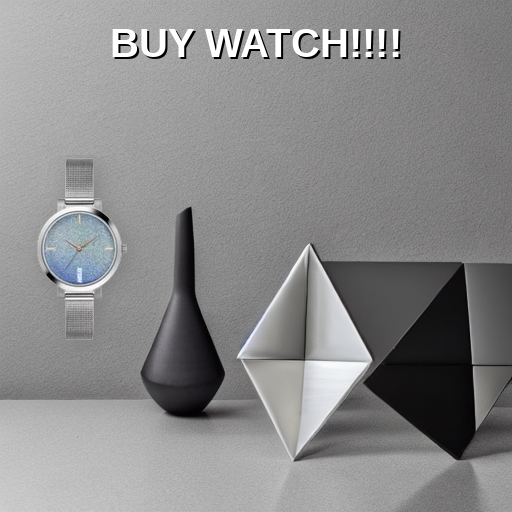

Final ad with text created successfully!


In [ ]:
from PIL import ImageDraw, ImageFont

# Load the final image
final_image = final_image.convert("RGBA")

# Get user input for the ad text
ad_text = "BUY WATCH!!!!"

# Initialize ImageDraw
draw = ImageDraw.Draw(final_image)

# Load a font (change path if needed)
font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"  # Use an available font
font_size = 40
font = ImageFont.truetype(font_path, font_size)

# Gets the size of the text
bbox = draw.textbbox((0, 0), ad_text, font=font)
text_width = bbox[2] - bbox[0]  # Width of the text
text_height = bbox[3] - bbox[1]  # Height of the text

# Position text at the bottom center
text_x = (final_image.width - text_width) // 2
text_y = 20  # 20px padding from the bottom

# Draw text with a shadow effect for better visibility
shadow_offset = 2
draw.text((text_x + shadow_offset, text_y + shadow_offset), ad_text, font=font, fill="black")  # Shadow
draw.text((text_x, text_y), ad_text, font=font, fill="white")  # Main text

# Save and display the final ad with text
final_image.save("/content/final_ad_with_text.png")
display(final_image)
print("Final ad with text created successfully!")


DOING UI INTEGRATION -HAS SOME ERRORS FOR NOW


In [ ]:
def run_generation(gender, baseColour, usage, subCategory, masterCategory, year, product_image):
    from rembg import remove
    from PIL import Image, ImageDraw, ImageStat, ImageFilter
    import numpy as np
    import torch

    # Step 1: Prepare metadata
    product_data = {
        "gender": gender,
        "baseColour": baseColour,
        "usage": usage,
        "subCategory": subCategory,
        "masterCategory": masterCategory,
        "year": year
    }

    # Step 2: Generate prompt and background
    ad_prompt = generate_prompt_for_ad_background(product_data)
    ad_background = generate_response(ad_prompt)
    ad_background_text = extract_ad_background(ad_background)
    bg_image = pipe(ad_background_text).images[0].convert("RGBA")

    # Step 3: Process product image
    product_with_bg = product_image.convert("RGB")
    product_no_bg = remove(product_with_bg)  # Transparent RGBA

    scale_factor = 0.3
    new_size = (int(product_no_bg.width * scale_factor), int(product_no_bg.height * scale_factor))
    product_no_bg = product_no_bg.resize(new_size, Image.LANCZOS)

    def create_shadow(product_image, blur_radius=10, opacity=0.5):
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()
        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))
        return shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    product_shadow = create_shadow(product_no_bg)

    # Step 4: Object detection
    model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True, verbose=False)
    results = model(bg_image)
    detections = results.pandas().xyxy[0]
    avoid_classes = ['person', 'cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'tree']
    avoid_boxes = [
        (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
        for _, row in detections.iterrows() if row['name'] in avoid_classes
    ]

    def is_overlapping(x, y, product_size, boxes):
        px1, py1 = x, y
        px2, py2 = x + product_size[0], y + product_size[1]
        for bx1, by1, bx2, by2 in boxes:
            if not (px2 < bx1 or px1 > bx2 or py2 < by1 or py1 > by2):
                return True
        return False

    # Step 5: Fake segmentation map
    segmentation_map = Image.new("L", bg_image.size)
    seg_draw = ImageDraw.Draw(segmentation_map)
    seg_draw.rectangle([0, 0, bg_image.width, bg_image.height * 0.25], fill=2)  # Sky
    seg_draw.rectangle([0, bg_image.height * 0.25, bg_image.width, bg_image.height], fill=1)  # Ground

    def segment_score(seg_map, pos, size):
        x, y = pos
        region = seg_map.crop((x, y, x + size[0], y + size[1]))
        arr = np.array(region)
        return np.sum(arr == 1) - np.sum(arr == 2)

    def score_region(region, position, image_size, segmentation_map):
        stats = ImageStat.Stat(region.convert('L'))
        variance = stats.var[0]
        mean_brightness = stats.mean[0]

        norm_variance = max(0, 1 - (variance / 1000))
        norm_brightness = 1 - abs(mean_brightness - 128) / 128
        vertical_bias = 1 - (position[1] / image_size[1])
        seg_score = segment_score(segmentation_map, position, region.size) / (region.size[0] * region.size[1])

        return norm_variance * 0.5 + norm_brightness * 0.5 + vertical_bias * 0.3 + seg_score * 0.5

    def find_best_placement(background, product_size, avoid_boxes, segmentation_map):
        best_score = -1
        best_position = None
        for y in range(0, background.height - product_size[1], 50):
            for x in range(0, background.width - product_size[0], 50):
                if is_overlapping(x, y, product_size, avoid_boxes):
                    continue
                region = background.crop((x, y, x + product_size[0], y + product_size[1]))
                score = score_region(region, (x, y), background.size, segmentation_map)
                if score > best_score:
                    best_score = score
                    best_position = (x, y)
        return best_position or (
            (background.width - product_size[0]) // 2,
            (background.height - product_size[1]) // 2
        )

    product_position = find_best_placement(bg_image, product_no_bg.size, avoid_boxes, segmentation_map)

    # Step 6: Composite final ad
    final_image = bg_image.copy()
    shadow_position = (product_position[0] + 5, product_position[1] + 5)
    final_image.paste(product_shadow, shadow_position, product_shadow)
    final_image.paste(product_no_bg, product_position, product_no_bg)

    return ad_background_text, final_image


In [ ]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("## 🖼️ Smart Ad Background & Product Overlay")

    with gr.Row():
        gender = gr.Textbox(label="Gender")
        baseColour = gr.Textbox(label="Base Colour")
        usage = gr.Textbox(label="Usage")

    with gr.Row():
        subCategory = gr.Textbox(label="Subcategory")
        masterCategory = gr.Textbox(label="Master Category")
        year = gr.Number(label="Year")

    product_input = gr.Image(label="Upload Product Image")

    generate_button = gr.Button("Generate Smart Ad")

    ad_text_output = gr.Textbox(label="Generated Background Description", lines=5)
    image_output = gr.Image(label="Final Ad with Product Placement")

    generate_button.click(
        fn=run_generation,
        inputs=[gender, baseColour, usage, subCategory, masterCategory, year, product_input],
        outputs=[ad_text_output, image_output]
    )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6959113ea6c4ba72ce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from PIL import Image, ImageDraw, ImageStat, ImageFilter
import numpy as np
import torch
from rembg import remove

# === Assume generate_prompt_for_ad_background, generate_response, extract_ad_background, pipe are defined ===

# === Helper for smart product placement ===
def smart_product_inlay(product_image, background_image):
    # Step 1: Remove product background
    product_with_bg = product_image.convert("RGB")
    product_no_bg = remove(product_with_bg)  # Transparent RGBA

    # Step 2: Resize
    scale_factor = 0.3
    new_size = (int(product_no_bg.width * scale_factor), int(product_no_bg.height * scale_factor))
    product_no_bg = product_no_bg.resize(new_size, Image.LANCZOS)

    # Step 3: Create shadow
    def create_shadow(product_image, blur_radius=10, opacity=0.5):
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]
        shadow_pixels = shadow.load()
        mask_pixels = mask.load()
        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))
        return shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    product_shadow = create_shadow(product_no_bg)

    # Step 4: Object detection to avoid
    model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True, verbose=False)
    results = model(background_image)
    detections = results.pandas().xyxy[0]
    avoid_classes = ['person', 'cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'tree']
    avoid_boxes = [
        (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
        for _, row in detections.iterrows() if row['name'] in avoid_classes
    ]

    def is_overlapping(x, y, product_size, boxes):
        px1, py1 = x, y
        px2, py2 = x + product_size[0], y + product_size[1]
        for bx1, by1, bx2, by2 in boxes:
            if not (px2 < bx1 or px1 > bx2 or py2 < by1 or py1 > by2):
                return True
        return False

    # Step 5: Simulate segmentation
    segmentation_map = Image.new("L", background_image.size)
    seg_draw = ImageDraw.Draw(segmentation_map)
    seg_draw.rectangle([0, 0, background_image.width, background_image.height * 0.25], fill=2)  # Sky
    seg_draw.rectangle([0, background_image.height * 0.25, background_image.width, background_image.height], fill=1)  # Ground

    def segment_score(segmentation_map, position, product_size):
        x, y = position
        region = segmentation_map.crop((x, y, x + product_size[0], y + product_size[1]))
        arr = np.array(region)
        return np.sum(arr == 1) - np.sum(arr == 2)

    def score_region(region, position, image_size, segmentation_map):
        stats = ImageStat.Stat(region.convert('L'))
        variance = stats.var[0]
        mean_brightness = stats.mean[0]
        norm_variance = max(0, 1 - (variance / 1000))
        norm_brightness = 1 - abs(mean_brightness - 128) / 128
        vertical_bias = 1 - (position[1] / image_size[1])
        seg_score = segment_score(segmentation_map, position, region.size) / (region.size[0] * region.size[1])
        return norm_variance * 0.5 + norm_brightness * 0.5 + vertical_bias * 0.3 + seg_score * 0.5

    def find_best_placement(background, product_size, avoid_boxes, segmentation_map):
        best_score = -1
        best_position = None
        for y in range(0, background.height - product_size[1], 50):
            for x in range(0, background.width - product_size[0], 50):
                if is_overlapping(x, y, product_size, avoid_boxes):
                    continue
                region = background.crop((x, y, x + product_size[0], y + product_size[1]))
                score = score_region(region, (x, y), background.size, segmentation_map)
                if score > best_score:
                    best_score = score
                    best_position = (x, y)
        return best_position or (
            (background.width - product_size[0]) // 2,
            (background.height - product_size[1]) // 2
        )

    # Step 6: Composite final image
    position = find_best_placement(background_image, product_no_bg.size, avoid_boxes, segmentation_map)
    final_image = background_image.copy()
    shadow_position = (position[0] + 5, position[1] + 5)
    final_image.paste(product_shadow, shadow_position, product_shadow)
    final_image.paste(product_no_bg, position, product_no_bg)

    return final_image

# === Main function: step 1 generate background, step 2 overlay product ===
bg_cache = {}

def generate_background(gender, baseColour, usage, subCategory, masterCategory, year):
    product_data = {
        "gender": gender,
        "baseColour": baseColour,
        "usage": usage,
        "subCategory": subCategory,
        "masterCategory": masterCategory,
        "year": year
    }
    ad_prompt = generate_prompt_for_ad_background(product_data)
    ad_background = generate_response(ad_prompt)
    ad_background_text = extract_ad_background(ad_background)
    bg_image = pipe(ad_background_text).images[0].convert("RGBA")
    bg_cache["background_image"] = bg_image  # store for next step
    return ad_background_text, bg_image

def overlay_product(product_image):
    if "background_image" not in bg_cache:
        raise ValueError("Background not generated yet!")
    background_image = bg_cache["background_image"]
    return smart_product_inlay(product_image, background_image)

# === Gradio UI ===
with gr.Blocks() as demo:
    gr.Markdown("## 🖼️ Smart Ad Generator with Product Placement")

    with gr.Row():
        gender = gr.Textbox(label="Gender")
        baseColour = gr.Textbox(label="Base Colour")
        usage = gr.Textbox(label="Usage")

    with gr.Row():
        subCategory = gr.Textbox(label="Subcategory")
        masterCategory = gr.Textbox(label="Master Category")
        year = gr.Number(label="Year")

    generate_bg_button = gr.Button("1️⃣ Generate Background")

    ad_text_output = gr.Textbox(label="Generated Background Description", lines=5)
    bg_image_output = gr.Image(label="Generated Background Image")

    generate_bg_button.click(
        fn=generate_background,
        inputs=[gender, baseColour, usage, subCategory, masterCategory, year],
        outputs=[ad_text_output, bg_image_output]
    )

    gr.Markdown("---")

    product_input = gr.Image(label="2️⃣ Upload Product Image", type="pil")
    overlay_button = gr.Button("Generate Final Ad")

    final_image_output = gr.Image(label="Final Ad with Smart Placement")

    overlay_button.click(
        fn=overlay_product,
        inputs=[product_input],
        outputs=[final_image_output]
    )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0954b2c1c5f5845c66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
